# Técnicas Aproximadas de Control por Refuerzo

---

## Objetivo

Implementar, entrenar y comparar dos métodos de control aproximado bajo un protocolo homogéneo:

| Método | Tipo de actualización | Aproximador | Representación de entrada |
|--------|------------------------|-------------|----------------------------|
| **SARSA semi-gradiente** | TD on-policy | Lineal | Común por entorno |
| **Deep Q-Network (DQN)** | TD off-policy | MLP | Común por entorno |

### Entornos

- **CartPole-v1** (Gymnasium): estado continuo 4D, útil como banco de prueba controlado.
- **Tetris** (`tetris_gymnasium/Tetris`): entorno de mayor complejidad estructural y fuerte dependencia de aproximación funcional.

### Criterios de comparabilidad

1. **Misma representación por entorno para ambos métodos**.
   En CartPole se usa una base de Fourier de orden 2 (`81` features) y en Tetris un vector artesanal de `7` descriptores del tablero.
2. **Mismo calendario de exploración por entorno**.
   `epsilon` parte del mismo valor inicial y decae por episodio para alcanzar el mismo `eps_end` al final del presupuesto disponible.
3. **Mismas semillas de entrenamiento y de evaluación**.
   Cada episodio se inicializa con `episode_seed(seed, ep)` y la evaluación final greedy (`epsilon=0`) usa exactamente la misma batería de semillas para SARSA y DQN.
4. **Mismas métricas de agregación**.
   Las medias y desviaciones finales se calculan sobre medias por semilla, evitando mezclar dispersión temporal intra-seed con variabilidad inter-seed.

### Alcance metodológico

El objetivo no es comparar dos pipelines con distinta información de entrada, sino contrastar dos estrategias de aprendizaje aproximado bajo una base experimental lo más alineada posible. Las diferencias observadas deben interpretarse, por tanto, como resultado combinado del esquema de actualización y del aproximador de valor, no de haber expuesto a cada método a observaciones distintas.

---

> **Reproducibilidad**: el notebook puede ejecutarse completo con `EXP_MODE=FULL` para resultados reportables o con `EXP_MODE=FAST` para validación rápida del pipeline.


In [1]:
# Instalación opcional de dependencias (solo si faltan en el entorno actual).
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    'gymnasium': 'gymnasium[classic-control]>=0.29',
    'tetris_gymnasium': 'tetris-gymnasium',
    'torch': 'torch>=2.0',
    'matplotlib': 'matplotlib>=3.7',
    'numpy': 'numpy>=1.24',
    'pandas': 'pandas>=2.0',
}

missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]

if missing:
    print('Instalando dependencias ausentes...')
    for pkg in missing:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
else:
    print('Dependencias ya disponibles; no se requiere instalación.')


Dependencias ya disponibles; no se requiere instalación.


In [2]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
from collections import deque
from itertools import product
from IPython.display import HTML, Markdown, display
from matplotlib import animation


def scheduled_eps_decay(eps_start: float, eps_end: float, n_episodes: int) -> float:
    '''Calcula el decaimiento multiplicativo por episodio que lleva epsilon desde eps_start hasta eps_end al final del presupuesto.

    Se usa para que SARSA y DQN consuman exploración al mismo ritmo nominal dentro de cada entorno.
    '''
    if n_episodes <= 0:
        raise ValueError('n_episodes debe ser positivo.')
    if not (0.0 < eps_end <= eps_start <= 1.0):
        raise ValueError('Se requiere 0 < eps_end <= eps_start <= 1.')
    return float((eps_end / eps_start) ** (1.0 / n_episodes))


EXP_MODE = os.getenv('EXP_MODE', 'FULL').upper()
if EXP_MODE not in {'FAST', 'FULL'}:
    raise ValueError(f"EXP_MODE inválido: {EXP_MODE}. Usa FAST o FULL.")

if EXP_MODE == 'FULL':
    SEEDS               = [0, 1, 2, 3, 4]
    N_EP_CARTPOLE       = 500
    N_EP_TETRIS         = 250
    MAX_STEPS_TETRIS    = 800
    SMOOTH_W            = 30
    W_FINAL_CARTPOLE    = 50
    W_FINAL_TETRIS      = 40
    EVAL_SEEDS_CARTPOLE = [10_000 + i for i in range(25)]
    EVAL_SEEDS_TETRIS   = [20_000 + i for i in range(20)]
else:
    SEEDS               = [0, 1, 2]
    N_EP_CARTPOLE       = 250
    N_EP_TETRIS         = 80
    MAX_STEPS_TETRIS    = 500
    SMOOTH_W            = 20
    W_FINAL_CARTPOLE    = 30
    W_FINAL_TETRIS      = 20
    EVAL_SEEDS_CARTPOLE = [10_000 + i for i in range(20)]
    EVAL_SEEDS_TETRIS   = [20_000 + i for i in range(10)]

MAX_STEPS_CARTPOLE = 500

EPS_START_CARTPOLE = 1.0
EPS_END_CARTPOLE   = 0.01
EPS_START_TETRIS   = 1.0
EPS_END_TETRIS     = 0.05

COMMON_EPS_DECAY_CP  = scheduled_eps_decay(EPS_START_CARTPOLE, EPS_END_CARTPOLE, N_EP_CARTPOLE)
COMMON_EPS_DECAY_TET = scheduled_eps_decay(EPS_START_TETRIS, EPS_END_TETRIS, N_EP_TETRIS)

# CartPole sí dispone de una referencia histórica ampliamente usada: el entorno se considera resuelto con retorno >= 195.
# Además se introduce un umbral operativo de saturación (95% del máximo 500) para distinguir "resuelto" de "casi perfecto".
CARTPOLE_SOLVED_RETURN = 195.0
CARTPOLE_NEAR_OPTIMAL_FRAC = 0.95
CARTPOLE_NEAR_OPTIMAL_RETURN = CARTPOLE_NEAR_OPTIMAL_FRAC * MAX_STEPS_CARTPOLE

# Estas ventanas solo resumen y visualizan el régimen final; no intervienen en el aprendizaje ni definen un "éxito" binario.
# Se escogen para promediar el tramo final y evitar que la comparación dependa del último episodio aislado.
DQN_LEARNING_STARTS_CP  = 256 if EXP_MODE == 'FULL' else 128
DQN_LEARNING_STARTS_TET = 512 if EXP_MODE == 'FULL' else 192

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch   : {torch.__version__}')
print(f'Gymnasium : {gym.__version__}')
print(f'Device    : {DEVICE}')
print(f'Modo      : {EXP_MODE}')
print(f'Train seeds: {SEEDS}')
print(f'CartPole  : {N_EP_CARTPOLE} episodios')
print(f'Tetris    : {N_EP_TETRIS} episodios')
print(f'Eval seeds CartPole/Tetris: {len(EVAL_SEEDS_CARTPOLE)}/{len(EVAL_SEEDS_TETRIS)}')
print('Calendario epsilon común por episodio:')
print(f'  CartPole -> start={EPS_START_CARTPOLE:.2f}, end={EPS_END_CARTPOLE:.2f}, decay={COMMON_EPS_DECAY_CP:.6f}')
print(f'  Tetris   -> start={EPS_START_TETRIS:.2f}, end={EPS_END_TETRIS:.2f}, decay={COMMON_EPS_DECAY_TET:.6f}')
print('Criterios de lectura de resultados:')
print(f'  CartPole resuelto -> retorno medio >= {CARTPOLE_SOLVED_RETURN:.0f} (criterio histórico de Gym/Gymnasium)')
print(f'  CartPole casi óptimo -> retorno medio >= {CARTPOLE_NEAR_OPTIMAL_RETURN:.0f} (= {100 * CARTPOLE_NEAR_OPTIMAL_FRAC:.0f}% del máximo {MAX_STEPS_CARTPOLE})')
print('  Tetris -> no se usa un umbral externo canónico; se compara por retornos exactos, estabilidad y coherencia train/eval')
print(f'  Ventana final CartPole/Tetris -> {W_FINAL_CARTPOLE}/{W_FINAL_TETRIS} episodios')
print(f'  Learning starts DQN CartPole/Tetris -> {DQN_LEARNING_STARTS_CP}/{DQN_LEARNING_STARTS_TET} transiciones')


PyTorch   : 2.10.0+cu128
Gymnasium : 1.2.3
Device    : cuda
Modo      : FULL
Train seeds: [0, 1, 2, 3, 4]
CartPole  : 500 episodios
Tetris    : 250 episodios
Eval seeds CartPole/Tetris: 25/20
Calendario epsilon común por episodio:
  CartPole -> start=1.00, end=0.01, decay=0.990832
  Tetris   -> start=1.00, end=0.05, decay=0.988089
Criterios de lectura de resultados:
  CartPole resuelto -> retorno medio >= 195 (criterio histórico de Gym/Gymnasium)
  CartPole casi óptimo -> retorno medio >= 475 (= 95% del máximo 500)
  Tetris -> no se usa un umbral externo canónico; se compara por retornos exactos, estabilidad y coherencia train/eval
  Ventana final CartPole/Tetris -> 50/40 episodios
  Learning starts DQN CartPole/Tetris -> 256/512 transiciones


In [3]:
# Se fijan semillas y opciones deterministas para garantizar reproducibilidad experimental.
def set_global_seed(seed: int):
    """Semillas en Python/NumPy/Torch + ajustes deterministas."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def episode_seed(base_seed: int, episode_idx: int) -> int:
    """Se usa la misma semilla por episodio para comparar SARSA y DQN bajo condiciones equivalentes."""
    return int(base_seed * 100_000 + episode_idx)


set_global_seed(SEEDS[0])
print(f'Semilla global fijada en {SEEDS[0]}.')


Semilla global fijada en 0.


In [4]:
# Se verifica CartPole para confirmar dimensiones de entrada y acciones disponibles.
_cp = gym.make('CartPole-v1')
_obs, _ = _cp.reset(seed=0)
print('CartPole-v1')
print('  obs shape   :', _obs.shape)
print('  action space:', _cp.action_space)
_cp.close()

# Se verifica Tetris para confirmar forma de tablero y número de acciones.
TETRIS_AVAILABLE = False
TETRIS_ENV_ID    = 'tetris_gymnasium/Tetris'
TETRIS_IN_DIM    = None
TETRIS_N_ACTIONS = None

try:
    from tetris_gymnasium.envs import Tetris as _TetrisEnvClass  # registra el env
    _tet = gym.make(TETRIS_ENV_ID)
    _obs_tet, _ = _tet.reset(seed=0)
    _board = _obs_tet['board'] if isinstance(_obs_tet, dict) else np.asarray(_obs_tet)
    _board = np.asarray(_board, dtype=np.float32)
    if _board.ndim > 2:
        _board = _board.squeeze()
    TETRIS_IN_DIM    = int(_board.flatten().shape[0])
    TETRIS_N_ACTIONS = int(_tet.action_space.n)
    TETRIS_AVAILABLE = True
    print()
    print('Tetris (' + TETRIS_ENV_ID + ')')
    print('  board shape :', _board.shape)
    print('  action space:', _tet.action_space)
    print('  raw board flat dim (referencia):', TETRIS_IN_DIM)
    _tet.close()
except Exception as _e:
    print()
    print('Tetris no disponible:', _e)
    print('Los experimentos con Tetris serán omitidos.')


CartPole-v1
  obs shape   : (4,)
  action space: Discrete(2)

Tetris (tetris_gymnasium/Tetris)
  board shape : (24, 18)
  action space: Discrete(8)
  raw board flat dim (referencia): 432


### Cierre de Infraestructura

Decisiones tomadas:

- Se valida disponibilidad de los entornos antes de entrenar para evitar ejecuciones parciales ambiguas.
- La configuración experimental queda centralizada (`EXP_MODE`, semillas, episodios, ventanas y calendario `epsilon`).
- El protocolo de comparabilidad se fija desde el inicio: misma representación, mismas semillas y misma pauta de exploración por entorno.
- `FAST` permite validar el pipeline; `FULL` produce la ejecución destinada al análisis final.


---
## 1. SARSA Semi-Gradiente

### Fundamento teórico

SARSA semi-gradiente (Sutton & Barto, §10.1) parametriza la función de valor-acción como:

$$Q(s, a; \mathbf{w}) = \mathbf{w}_a^\top \boldsymbol{\phi}(s)$$

con actualización:

$$\mathbf{w}_a \leftarrow \mathbf{w}_a + \alpha \bigl[r + \gamma Q(s', a'; \mathbf{w}) - Q(s, a; \mathbf{w})\bigr] \boldsymbol{\phi}(s).$$

### Representación compartida por entorno

- **CartPole**: base de Fourier coseno de orden 2 (`81` features), adecuada para un estado continuo de baja dimensión.
- **Tetris**: vector de `7` rasgos del tablero (altura agregada, altura máxima, huecos, rugosidad, desviación típica de alturas, líneas completas y pozos).

Estas mismas representaciones se reutilizarán más adelante en DQN. De este modo, la comparación no queda contaminada por diferencias en la información de entrada.

### Control de comparabilidad

Durante entrenamiento, cada episodio usa `episode_seed(seed, ep)` para que SARSA y DQN vean episodios equivalentes. Además, ambos comparten el mismo calendario `epsilon` por entorno y la misma batería de evaluación greedy final (`epsilon=0`).


In [5]:
# Se construyen los extractores de características que usarán ambos métodos.
CARTPOLE_LOW  = np.array([-4.8, -3.5, -0.42, -3.5], dtype=np.float64)
CARTPOLE_HIGH = np.array([ 4.8,  3.5,  0.42,  3.5], dtype=np.float64)

class FourierFeatures:
    '''Base de Fourier coseno para aproximación lineal en espacios continuos acotados.

    La literatura de control aproximado la usa con frecuencia en dominios continuos de baja dimensión
    porque introduce no linealidad en la representación sin abandonar un modelo lineal en los parámetros.
    '''
    def __init__(self, obs_low, obs_high, order=2):
        self.low = np.asarray(obs_low, dtype=np.float64)
        self.rng = np.asarray(obs_high, dtype=np.float64) - self.low + 1e-8
        indices = list(product(range(order + 1), repeat=len(self.low)))
        self.C = np.array(indices, dtype=np.float64)
        self.n_features = len(self.C)

    def __call__(self, obs):
        '''Mapea una observación continua al vector de características phi(s).'''
        s = np.clip(np.asarray(obs, dtype=np.float64), self.low, self.low + self.rng)
        s_norm = (s - self.low) / self.rng
        return np.cos(np.pi * (self.C @ s_norm))

    def alpha_scaling(self):
        '''Escala alpha por frecuencia para estabilizar el aprendizaje con bases de Fourier.'''
        norms = np.linalg.norm(self.C, axis=1)
        norms[norms == 0] = 1.0
        return 1.0 / norms


def cartpole_featurize(obs, feat):
    '''Convierte una observación de CartPole en features float32 reutilizables por SARSA y DQN.'''
    return feat(obs).astype(np.float32)


N_TETRIS_FEAT = 7


def _get_board(obs):
    '''Extrae el tablero 2D desde la observación del entorno Tetris, independientemente del envoltorio usado.'''
    if isinstance(obs, dict):
        board = obs.get('board', list(obs.values())[0])
    else:
        board = obs
    board = np.asarray(board, dtype=np.float32)
    if board.ndim > 2:
        board = board.squeeze()
    return board


def tetris_featurize(obs):
    '''Construye un vector normalizado de 7 descriptores estructurales del tablero.

    Los rasgos son: altura agregada, altura máxima, huecos, rugosidad, desviación típica de alturas,
    líneas completas y pozos. Se usan como representación compartida entre SARSA y DQN para que la
    comparación recaiga sobre el algoritmo y el aproximador, no sobre información de entrada distinta.
    '''
    board = _get_board(obs)
    H, W = board.shape
    heights = np.zeros(W, dtype=np.float32)
    for c in range(W):
        filled = np.where(board[:, c] > 0)[0]
        if len(filled) > 0:
            heights[c] = H - filled[0]

    agg_h = float(heights.sum())
    max_h = float(heights.max())
    bumpy = float(np.abs(np.diff(heights)).sum())
    std_h = float(heights.std())
    complete = float(np.all(board > 0, axis=1).sum())

    holes = 0.0
    for c in range(W):
        found_top = False
        for cell in board[:, c]:
            if cell > 0:
                found_top = True
            elif found_top:
                holes += 1

    wells = 0.0
    for c in range(W):
        left = heights[c - 1] if c > 0 else float(H)
        right = heights[c + 1] if c < W - 1 else float(H)
        depth = min(left, right) - heights[c]
        if depth > 0:
            wells += depth

    divs = np.array([H * W, H, H * W / 4.0, H * W, H, 4.0, H * W], dtype=np.float32) + 1e-8
    raw = np.array([agg_h, max_h, holes, bumpy, std_h, complete, wells], dtype=np.float32)
    return np.clip(raw / divs, 0.0, 1.0)


_ff = FourierFeatures(CARTPOLE_LOW, CARTPOLE_HIGH, order=2)
print(f'FourierFeatures order=2 -> {_ff.n_features} features')
print(f'Tetris handcrafted features -> {N_TETRIS_FEAT} values')


FourierFeatures order=2 -> 81 features
Tetris handcrafted features -> 7 values


In [6]:
# Se implementa el agente SARSA lineal con política epsilon-greedy y update semi-gradiente.
class SarsaLinearAgent:
    '''Agente SARSA semi-gradiente lineal.

    Cada acción dispone de su propio vector de pesos. La actualización sigue el target on-policy
    r + gamma * Q(s', a'), por lo que la política de comportamiento y la política objetivo coinciden.
    '''
    def __init__(self, n_features, n_actions, alpha=5e-3, gamma=0.99,
                 eps_start=1.0, eps_end=0.01, eps_decay=0.995, alpha_scales=None):
        self.n_actions = n_actions
        self.gamma     = gamma
        self.epsilon   = eps_start
        self.eps_end   = eps_end
        self.eps_decay = eps_decay
        # Se inicializa una fila de pesos por acción, cada una sobre el vector de features.
        self.weights   = np.zeros((n_actions, n_features), dtype=np.float64)
        # En Fourier se escala alpha por frecuencia para que las componentes de alta frecuencia no dominen el update.
        self.alpha = (alpha * alpha_scales.astype(np.float64)
                      if alpha_scales is not None else float(alpha))

    def q_values(self, phi):
        '''Evalúa Q(s, ·) para el vector de características actual.''' 
        return self.weights @ phi

    def select_action(self, phi):
        '''Aplica epsilon-greedy sobre los valores-acción aproximados.''' 
        if np.random.random() < self.epsilon:
            return int(np.random.randint(self.n_actions))
        return int(np.argmax(self.q_values(phi)))

    def update(self, phi, action, reward, phi_next, next_action, done):
        '''Ejecuta un paso de SARSA semi-gradiente lineal sobre la acción realmente seguida.''' 
        q_cur  = float(self.weights[action] @ phi)
        q_next = 0.0 if done else float(self.weights[next_action] @ phi_next)
        delta  = reward + self.gamma * q_next - q_cur
        self.weights[action] += self.alpha * delta * phi
        return delta

    def decay_epsilon(self):
        '''Reduce epsilon por episodio hasta el mínimo fijado para mantener comparabilidad con DQN.''' 
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)

print('SarsaLinearAgent definido.')


SarsaLinearAgent definido.


In [7]:
def train_sarsa_cartpole(seed=0, n_episodes=N_EP_CARTPOLE,
                         alpha=3e-3, gamma=0.99,
                         eps_start=EPS_START_CARTPOLE, eps_end=EPS_END_CARTPOLE,
                         eps_decay=COMMON_EPS_DECAY_CP, fourier_order=2,
                         max_steps=MAX_STEPS_CARTPOLE, return_agent=False):
    '''Entrena SARSA semi-gradiente en CartPole con la misma base de Fourier que usará DQN.

    El decaimiento epsilon se aplica por episodio para que la cantidad de exploración dependa solo del
    presupuesto experimental y no de la longitud media de los episodios.
    '''
    set_global_seed(seed)
    env = gym.make('CartPole-v1')
    env.action_space.seed(seed)
    if hasattr(env.observation_space, 'seed'):
        env.observation_space.seed(seed)

    feat = FourierFeatures(CARTPOLE_LOW, CARTPOLE_HIGH, order=fourier_order)
    agent = SarsaLinearAgent(
        feat.n_features, env.action_space.n,
        alpha=alpha, gamma=gamma,
        eps_start=eps_start, eps_end=eps_end, eps_decay=eps_decay,
        alpha_scales=feat.alpha_scaling()
    )

    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=episode_seed(seed, ep))
        phi = feat(obs)
        action = agent.select_action(phi)
        ep_ret, done, steps = 0.0, False, 0
        while not done and steps < max_steps:
            next_obs, r, term, trunc, _ = env.step(action)
            done = term or trunc
            phi_next = feat(next_obs)
            next_action = 0 if done else agent.select_action(phi_next)
            agent.update(phi, action, r, phi_next, next_action, done)
            ep_ret += r
            phi, action = phi_next, next_action
            steps += 1
        agent.decay_epsilon()
        returns.append(ep_ret)

    env.close()
    if return_agent:
        return returns, agent, feat
    return returns


def train_sarsa_tetris(seed=0, n_episodes=N_EP_TETRIS,
                       alpha=1e-2, gamma=0.99,
                       eps_start=EPS_START_TETRIS, eps_end=EPS_END_TETRIS,
                       eps_decay=COMMON_EPS_DECAY_TET,
                       max_steps=MAX_STEPS_TETRIS, return_agent=False):
    '''Entrena SARSA semi-gradiente en Tetris sobre la representación compacta compartida de 7 rasgos.'''
    set_global_seed(seed)
    from tetris_gymnasium.envs import Tetris as _TetrisEnvClass
    env = gym.make(TETRIS_ENV_ID)
    env.action_space.seed(seed)
    if hasattr(env.observation_space, 'seed'):
        env.observation_space.seed(seed)

    agent = SarsaLinearAgent(
        N_TETRIS_FEAT, env.action_space.n,
        alpha=alpha, gamma=gamma,
        eps_start=eps_start, eps_end=eps_end, eps_decay=eps_decay
    )

    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=episode_seed(seed, ep))
        phi = tetris_featurize(obs)
        action = agent.select_action(phi)
        ep_ret, done, steps = 0.0, False, 0
        while not done and steps < max_steps:
            next_obs, r, term, trunc, _ = env.step(action)
            done = term or trunc
            phi_next = tetris_featurize(next_obs)
            next_action = 0 if done else agent.select_action(phi_next)
            agent.update(phi, action, r, phi_next, next_action, done)
            ep_ret += r
            phi, action = phi_next, next_action
            steps += 1
        agent.decay_epsilon()
        returns.append(ep_ret)

    env.close()
    if return_agent:
        return returns, agent
    return returns


def evaluate_sarsa_cartpole(agent, feat, eval_seeds=EVAL_SEEDS_CARTPOLE,
                            max_steps=MAX_STEPS_CARTPOLE):
    '''Evalúa la política greedy de SARSA en CartPole con una batería fija de semillas independientes.''' 
    env = gym.make('CartPole-v1')
    rets = []
    for s in eval_seeds:
        obs, _ = env.reset(seed=s)
        phi = feat(obs)
        done, ep_ret, steps = False, 0.0, 0
        while not done and steps < max_steps:
            action = int(np.argmax(agent.q_values(phi)))
            next_obs, r, term, trunc, _ = env.step(action)
            done = term or trunc
            ep_ret += r
            phi = feat(next_obs)
            steps += 1
        rets.append(ep_ret)
    env.close()
    return np.array(rets, dtype=float)


def evaluate_sarsa_tetris(agent, eval_seeds=EVAL_SEEDS_TETRIS,
                          max_steps=MAX_STEPS_TETRIS):
    '''Evalúa la política greedy de SARSA en Tetris bajo las mismas semillas que se usarán con DQN.''' 
    from tetris_gymnasium.envs import Tetris as _TetrisEnvClass
    env = gym.make(TETRIS_ENV_ID)
    rets = []
    for s in eval_seeds:
        obs, _ = env.reset(seed=s)
        phi = tetris_featurize(obs)
        done, ep_ret, steps = False, 0.0, 0
        while not done and steps < max_steps:
            action = int(np.argmax(agent.q_values(phi)))
            next_obs, r, term, trunc, _ = env.step(action)
            done = term or trunc
            ep_ret += r
            phi = tetris_featurize(next_obs)
            steps += 1
        rets.append(ep_ret)
    env.close()
    return np.array(rets, dtype=float)


print('Funciones SARSA definidas (train + eval fija).')


Funciones SARSA definidas (train + eval fija).


### Implementación SARSA

Criterios de diseño:

- Aproximador lineal para mantener interpretabilidad del update semi-gradiente.
- Misma representación de entrada que usará DQN más adelante en cada entorno.
- Decaimiento `epsilon` por episodio, común por entorno, para que ambos métodos consuman exploración al mismo ritmo nominal.
- Evaluación greedy separada (`epsilon=0`) para medir la política final sin ruido de exploración.


### 1.1 SARSA en CartPole-v1

Se ejecuta con múltiples semillas (`SEEDS`) para estimar variabilidad.
La curva muestra media móvil (ventana `SMOOTH_W`) con banda ±1σ entre semillas.
La comparación final no depende solo de train: se usa también evaluación fija `epsilon=0`.


In [8]:
# Se entrena SARSA en CartPole para todas las semillas de entrenamiento.
print(f'Entrenando SARSA CartPole ({N_EP_CARTPOLE} ep x {len(SEEDS)} semillas)...')
sarsa_cp_all, sarsa_cp_eval = [], []
sarsa_cp_demo_agent, sarsa_cp_demo_feat = None, None

for s in SEEDS:
    print(f'  seed={s}...', end=' ', flush=True)
    rets, agent, feat = train_sarsa_cartpole(seed=s, eps_decay=COMMON_EPS_DECAY_CP, return_agent=True)
    # La evaluación fija sin exploración permite comparar políticas finales en condiciones equivalentes.
    eval_rets = evaluate_sarsa_cartpole(agent, feat)
    print(f'train-ult{W_FINAL_CARTPOLE}={np.mean(rets[-W_FINAL_CARTPOLE:]):.1f} | eval={np.mean(eval_rets):.1f}')
    sarsa_cp_all.append(rets)
    sarsa_cp_eval.append(eval_rets)
    if s == SEEDS[0]:
        sarsa_cp_demo_agent, sarsa_cp_demo_feat = agent, feat

sarsa_cp_all  = np.array(sarsa_cp_all)   # (n_seeds, n_episodes)
sarsa_cp_eval = np.array(sarsa_cp_eval)  # (n_seeds, n_eval_episodes)
print('Listo.')


Entrenando SARSA CartPole (500 ep x 5 semillas)...
  seed=0... train-ult50=500.0 | eval=500.0
  seed=1... train-ult50=500.0 | eval=500.0
  seed=2... train-ult50=500.0 | eval=500.0
  seed=3... train-ult50=500.0 | eval=500.0
  seed=4... train-ult50=500.0 | eval=500.0
Listo.


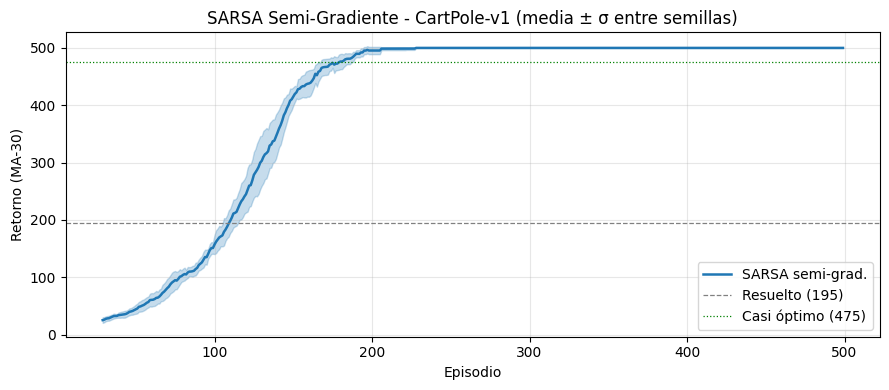

Train media final (media de semillas, ult.50 ep): 500.0 +/- 0.0
Eval greedy final (media de semillas): 500.0 +/- 0.0


In [9]:
# Utilidades de resumen y visualización comunes a todo el notebook.
def smooth(arr, w=SMOOTH_W):
    '''Media móvil en modo valid para visualizar tendencia sin alterar los datos crudos.'''
    arr = np.asarray(arr, dtype=float)
    if len(arr) < w:
        return arr.copy()
    return np.convolve(arr, np.ones(w) / w, mode='valid')


def smooth_x(raw_len, w=SMOOTH_W):
    '''Alinea el eje x con una media móvil calculada en modo valid.'''
    if raw_len < w:
        return np.arange(raw_len)
    return np.arange(w - 1, raw_len)


def plot_band(ax, returns_all, color, label, w=SMOOTH_W):
    '''Dibuja la media suavizada y la banda de +-1 desviación típica entre semillas.'''
    sm = np.array([smooth(r, w) for r in returns_all])
    n = min(len(s) for s in sm)
    sm = np.vstack([s[:n] for s in sm])
    x = smooth_x(returns_all.shape[1], w)[:n]
    mean, std = sm.mean(0), sm.std(0)
    ax.plot(x, mean, color=color, label=label, linewidth=1.8)
    ax.fill_between(x, mean - std, mean + std, alpha=0.25, color=color)


def final_window_seed_means(train_arr, w):
    '''Promedia la ventana final de cada semilla para resumir el régimen terminal de entrenamiento.'''
    return np.asarray(train_arr[:, -w:].mean(axis=1), dtype=float)


def initial_window_seed_means(train_arr, w):
    '''Promedia la ventana inicial de cada semilla para cuantificar la ganancia neta durante el aprendizaje.'''
    return np.asarray(train_arr[:, :w].mean(axis=1), dtype=float)


def seed_mean_stats(values):
    '''Devuelve media, desviación típica poblacional y vector original de una colección de semillas.'''
    values = np.asarray(values, dtype=float)
    return float(values.mean()), float(values.std()), values


def eval_seed_means(eval_arr):
    '''Resume cada semilla de evaluación greedy por la media de sus episodios evaluados.'''
    return np.asarray(eval_arr.mean(axis=1), dtype=float)


def best_smoothed_episode(train_arr, w=SMOOTH_W):
    '''Localiza el episodio asociado al máximo de la curva media suavizada.

    Es una métrica descriptiva del gráfico; no se usa para declarar superioridad estadística.
    '''
    sm = np.array([smooth(r, w) for r in train_arr])
    n = min(len(s) for s in sm)
    sm = np.vstack([s[:n] for s in sm])
    x = smooth_x(train_arr.shape[1], w)[:n]
    return int(x[int(sm.mean(0).argmax())])


def first_smoothed_crossing(train_arr, threshold, w=SMOOTH_W):
    '''Primer episodio en que la media suavizada supera un umbral descriptivo.

    En CartPole se usa con dos referencias explícitas: 195 puntos como criterio histórico de entorno resuelto
    y 475 puntos (=95% del máximo 500) como proxy operativo de saturación casi óptima.
    '''
    sm = np.array([smooth(r, w) for r in train_arr])
    n = min(len(s) for s in sm)
    sm = np.vstack([s[:n] for s in sm])
    mean_curve = sm.mean(0)
    x = smooth_x(train_arr.shape[1], w)[:n]
    idx = np.where(mean_curve >= threshold)[0]
    return int(x[idx[0]]) if len(idx) else None


def fmt_episode(ep):
    '''Formatea un episodio o informa de que el hito no se alcanzó en el presupuesto disponible.'''
    return f'episodio {ep:,}' if ep is not None else 'no alcanzado en el experimento'


def describe_gap(delta, tol=1e-12):
    '''Describe únicamente el signo de una diferencia.

    El parámetro tol es solo una salvaguarda numérica frente al redondeo binario; no representa un umbral metodológico.
    '''
    if delta > tol:
        return 'supera'
    if delta < -tol:
        return 'queda por debajo de'
    return 'coincide con'


def compare_at_precision(a, b, decimals):
    '''Compara dos métricas a la misma precisión con la que se reportan en el informe.

    Con ello se evita introducir umbrales ad hoc de "ventaja práctica": solo hay empate si ambas cifras
    coinciden tras el mismo redondeo que verá el lector en la tabla o en el markdown.
    '''
    fa = float(f'{float(a):.{decimals}f}')
    fb = float(f'{float(b):.{decimals}f}')
    return int(fa > fb) - int(fa < fb)


fig, ax = plt.subplots(figsize=(9, 4))
plot_band(ax, sarsa_cp_all, '#1f77b4', 'SARSA semi-grad.')
ax.axhline(CARTPOLE_SOLVED_RETURN, color='gray', linestyle='--', linewidth=0.9,
           label=f'Resuelto ({CARTPOLE_SOLVED_RETURN:.0f})')
ax.axhline(CARTPOLE_NEAR_OPTIMAL_RETURN, color='green', linestyle=':', linewidth=0.9,
           label=f'Casi óptimo ({CARTPOLE_NEAR_OPTIMAL_RETURN:.0f})')
ax.set_xlabel('Episodio')
ax.set_ylabel(f'Retorno (MA-{SMOOTH_W})')
ax.set_title('SARSA Semi-Gradiente - CartPole-v1 (media ± σ entre semillas)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

_cp_train_seed = final_window_seed_means(sarsa_cp_all, W_FINAL_CARTPOLE)
_cp_eval_seed = eval_seed_means(sarsa_cp_eval)
print(f'Train media final (media de semillas, ult.{W_FINAL_CARTPOLE} ep): {_cp_train_seed.mean():.1f} +/- {_cp_train_seed.std():.1f}')
print(f'Eval greedy final (media de semillas): {_cp_eval_seed.mean():.1f} +/- {_cp_eval_seed.std():.1f}')


In [10]:
# Interpretación dinámica de SARSA en CartPole.
_train_mean, _train_std, _train_seed = seed_mean_stats(final_window_seed_means(sarsa_cp_all, W_FINAL_CARTPOLE))
_eval_mean, _eval_std, _eval_seed = seed_mean_stats(eval_seed_means(sarsa_cp_eval))
_cross_195 = first_smoothed_crossing(sarsa_cp_all, CARTPOLE_SOLVED_RETURN)
_cross_475 = first_smoothed_crossing(sarsa_cp_all, CARTPOLE_NEAR_OPTIMAL_RETURN)
_best_ep = best_smoothed_episode(sarsa_cp_all)
_gap = _eval_mean - _train_mean
_train_pct = 100.0 * _train_mean / MAX_STEPS_CARTPOLE
_eval_pct = 100.0 * _eval_mean / MAX_STEPS_CARTPOLE
_gap_pct = 100.0 * _gap / MAX_STEPS_CARTPOLE

if compare_at_precision(_eval_std, 0.0, 2) == 0:
    _stability_note = 'A la precisión reportada, la desviación inter-semillas de la evaluación greedy es nula; las ejecuciones convergen al mismo rendimiento observable.'
else:
    _stability_note = (
        f'La desviación inter-semillas de la evaluación greedy es de **{_eval_std:.2f}** puntos, '
        'magnitud que cuantifica directamente cuánta dispersión queda entre ejecuciones independientes.'
    )

_gap_note = (
    f'La evaluación greedy **{describe_gap(_gap)}** el promedio final de entrenamiento en **{abs(_gap):.2f}** puntos '
    f'(**{abs(_gap_pct):.2f}%** del máximo teórico de {MAX_STEPS_CARTPOLE}).'
)

display(Markdown(f'''#### Interpretación — SARSA en CartPole-v1

**Desempeño final de la política greedy.**
SARSA alcanza un retorno medio final de **{_eval_mean:.2f} ± {_eval_std:.2f}** en evaluación greedy. Ese valor equivale al **{_eval_pct:.2f}%** del máximo teórico de CartPole (`500`). En la ventana final de entrenamiento obtiene **{_train_mean:.2f} ± {_train_std:.2f}**, esto es, **{_train_pct:.2f}%** del máximo.

**Velocidad de convergencia observada en entrenamiento.**
La media móvil agregada supera el umbral clásico de entorno resuelto (**{CARTPOLE_SOLVED_RETURN:.0f}**) en el **{fmt_episode(_cross_195)}**. Además entra en la franja de comportamiento casi saturado (**{CARTPOLE_NEAR_OPTIMAL_RETURN:.0f} = 95% del máximo**) en el **{fmt_episode(_cross_475)}**. El máximo de la curva suavizada aparece en el **{fmt_episode(_best_ep)}**, lo que ayuda a localizar cuándo se consolida el mejor tramo medio observado.

**Estabilidad y coherencia train/eval.**
{_stability_note}
{_gap_note}

**Lectura metodológica.**
La interpretación se apoya en criterios explícitos: `195` es la referencia histórica de CartPole resuelto y `475` es un umbral operativo de saturación, no un estándar externo. Bajo la representación de Fourier compartida y el mismo calendario `epsilon` por episodio que usará DQN, estas cifras permiten juzgar a SARSA por rapidez, nivel final y robustez sin introducir umbrales ad hoc adicionales.
'''))


#### Interpretación — SARSA en CartPole-v1

**Desempeño final de la política greedy.**
SARSA alcanza un retorno medio final de **500.00 ± 0.00** en evaluación greedy. Ese valor equivale al **100.00%** del máximo teórico de CartPole (`500`). En la ventana final de entrenamiento obtiene **500.00 ± 0.00**, esto es, **100.00%** del máximo.

**Velocidad de convergencia observada en entrenamiento.**
La media móvil agregada supera el umbral clásico de entorno resuelto (**195**) en el **episodio 110**. Además entra en la franja de comportamiento casi saturado (**475 = 95% del máximo**) en el **episodio 179**. El máximo de la curva suavizada aparece en el **episodio 228**, lo que ayuda a localizar cuándo se consolida el mejor tramo medio observado.

**Estabilidad y coherencia train/eval.**
A la precisión reportada, la desviación inter-semillas de la evaluación greedy es nula; las ejecuciones convergen al mismo rendimiento observable.
La evaluación greedy **coincide con** el promedio final de entrenamiento en **0.00** puntos (**0.00%** del máximo teórico de 500).

**Lectura metodológica.**
La interpretación se apoya en criterios explícitos: `195` es la referencia histórica de CartPole resuelto y `475` es un umbral operativo de saturación, no un estándar externo. Bajo la representación de Fourier compartida y el mismo calendario `epsilon` por episodio que usará DQN, estas cifras permiten juzgar a SARSA por rapidez, nivel final y robustez sin introducir umbrales ad hoc adicionales.


### 1.2 SARSA en Tetris

En Tetris se mantiene la misma lógica on-policy, pero sobre una representación compacta de `7` rasgos del tablero. El objetivo aquí no es alcanzar un óptimo teórico, sino evaluar si el método consigue extraer una política estable y reproducible con un aproximador lineal de capacidad limitada.


In [11]:
# Se entrena SARSA en Tetris para todas las semillas y luego se evalúa sin exploración.
sarsa_tet_all, sarsa_tet_eval = None, None
sarsa_tet_demo_agent = None

if TETRIS_AVAILABLE:
    print(f'Entrenando SARSA Tetris ({N_EP_TETRIS} ep x {len(SEEDS)} semillas)...')
    _tmp_train, _tmp_eval = [], []
    for s in SEEDS:
        print(f'  seed={s}...', end=' ', flush=True)
        rets, agent = train_sarsa_tetris(seed=s, eps_decay=COMMON_EPS_DECAY_TET, return_agent=True)
        eval_rets = evaluate_sarsa_tetris(agent)
        print(f'train-ult{W_FINAL_TETRIS}={np.mean(rets[-W_FINAL_TETRIS:]):.3f} | eval={np.mean(eval_rets):.3f}')
        _tmp_train.append(rets)
        _tmp_eval.append(eval_rets)
        if s == SEEDS[0]:
            sarsa_tet_demo_agent = agent

    sarsa_tet_all  = np.array(_tmp_train)
    sarsa_tet_eval = np.array(_tmp_eval)
    print('ok.')

Entrenando SARSA Tetris (250 ep x 5 semillas)...
  seed=0... train-ult40=9.725 | eval=9.950
  seed=1... train-ult40=9.750 | eval=9.950
  seed=2... train-ult40=9.800 | eval=9.950
  seed=3... train-ult40=9.975 | eval=9.950
  seed=4... train-ult40=9.800 | eval=9.950
ok.


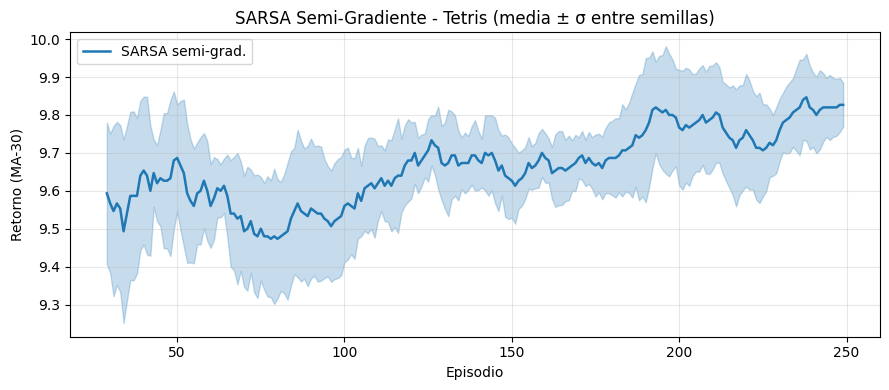

Train media final (media de semillas, ult.40 ep): 9.810 +/- 0.087
Eval greedy final (media de semillas): 9.950 +/- 0.000


In [12]:
# Se visualiza entrenamiento de SARSA en Tetris y se reporta resumen train/eval.
if sarsa_tet_all is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    plot_band(ax, sarsa_tet_all, '#1f77b4', 'SARSA semi-grad.')
    ax.set_xlabel('Episodio')
    ax.set_ylabel(f'Retorno (MA-{SMOOTH_W})')
    ax.set_title('SARSA Semi-Gradiente - Tetris (media ± σ entre semillas)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    _tet_train_seed = final_window_seed_means(sarsa_tet_all, W_FINAL_TETRIS)
    _tet_eval_seed = eval_seed_means(sarsa_tet_eval)
    print(f'Train media final (media de semillas, ult.{W_FINAL_TETRIS} ep): {_tet_train_seed.mean():.3f} +/- {_tet_train_seed.std():.3f}')
    print(f'Eval greedy final (media de semillas): {_tet_eval_seed.mean():.3f} +/- {_tet_eval_seed.std():.3f}')
else:
    print('Sin datos de Tetris.')


In [13]:
# Interpretación dinámica de SARSA en Tetris.
if sarsa_tet_all is None:
    display(Markdown('''#### Interpretación — SARSA en Tetris

Tetris no estuvo disponible en esta ejecución.'''))
else:
    _train_mean, _train_std, _train_seed = seed_mean_stats(final_window_seed_means(sarsa_tet_all, W_FINAL_TETRIS))
    _eval_mean, _eval_std, _eval_seed = seed_mean_stats(eval_seed_means(sarsa_tet_eval))
    _init_mean, _, _ = seed_mean_stats(initial_window_seed_means(sarsa_tet_all, W_FINAL_TETRIS))
    _gain = _train_mean - _init_mean
    _best_ep = best_smoothed_episode(sarsa_tet_all)
    _gap = _eval_mean - _train_mean

    if compare_at_precision(_eval_std, 0.0, 3) == 0:
        _seed_note = 'A la precisión reportada, la desviación inter-semillas de la evaluación greedy es nula; las semillas evaluadas convergen al mismo rendimiento observable.'
    else:
        _seed_note = f'La desviación inter-semillas en evaluación es **{_eval_std:.3f}**, lo que indica una variabilidad final reducida.'

    if compare_at_precision(_gain, 0.0, 3) > 0:
        _gain_note = f'La media final mejora en **{_gain:.3f}** puntos respecto a la ventana inicial.'
    elif compare_at_precision(_gain, 0.0, 3) < 0:
        _gain_note = f'La media final queda **{abs(_gain):.3f}** puntos por debajo de la ventana inicial, de modo que no se observa una ganancia neta al comparar ambos tramos agregados.'
    else:
        _gain_note = 'A la precisión reportada, la media final coincide con la ventana inicial.'

    display(Markdown(f'''#### Interpretación — SARSA en Tetris

**Desempeño final de la política greedy.**
SARSA alcanza un retorno greedy de **{_eval_mean:.3f} ± {_eval_std:.3f}**, con un rendimiento de entrenamiento final de **{_train_mean:.3f} ± {_train_std:.3f}**. Dado que en Tetris no se fija un umbral externo de éxito, esta cifra debe interpretarse de forma relativa dentro del propio experimento. Lo relevante aquí es que la política greedy final es estable y reproducible bajo una representación compacta.

**Evolución del aprendizaje.**
{_gain_note} El mejor tramo suavizado aparece en el **{fmt_episode(_best_ep)}**. La curva presenta un patrón relativamente estable, sin oscilaciones bruscas, lo que es coherente con un aproximador lineal de baja capacidad y una señal de recompensa difícil.

**Coherencia train/eval y estabilidad.**
La diferencia entre evaluación greedy y entrenamiento final es de **{_gap:+.3f}** puntos. {_seed_note}

**Lectura metodológica.**
Bajo este presupuesto y esta representación, SARSA converge a una política greedy muy estable. Esta lectura no implica optimalidad global en Tetris; solo indica que, dentro del protocolo del experimento, el método explota de forma consistente la información disponible.
'''))


#### Interpretación — SARSA en Tetris

**Desempeño final de la política greedy.**
SARSA alcanza un retorno greedy de **9.950 ± 0.000**, con un rendimiento de entrenamiento final de **9.810 ± 0.087**. Dado que en Tetris no se fija un umbral externo de éxito, esta cifra debe interpretarse de forma relativa dentro del propio experimento. Lo relevante aquí es que la política greedy final es estable y reproducible bajo una representación compacta.

**Evolución del aprendizaje.**
La media final mejora en **0.180** puntos respecto a la ventana inicial. El mejor tramo suavizado aparece en el **episodio 238**. La curva presenta un patrón relativamente estable, sin oscilaciones bruscas, lo que es coherente con un aproximador lineal de baja capacidad y una señal de recompensa difícil.

**Coherencia train/eval y estabilidad.**
La diferencia entre evaluación greedy y entrenamiento final es de **+0.140** puntos. A la precisión reportada, la desviación inter-semillas de la evaluación greedy es nula; las semillas evaluadas convergen al mismo rendimiento observable.

**Lectura metodológica.**
Bajo este presupuesto y esta representación, SARSA converge a una política greedy muy estable. Esta lectura no implica optimalidad global en Tetris; solo indica que, dentro del protocolo del experimento, el método explota de forma consistente la información disponible.


## 2. Deep Q-Network (DQN)

### Fundamento teórico

DQN (Mnih et al., 2015) parametriza $Q(s,\cdot;\theta)$ con una red neuronal y añade dos mecanismos de estabilización:

1. **Replay buffer** para romper correlación temporal.
2. **Target network** para desacoplar el objetivo TD del estimador online.

El objetivo de entrenamiento es:

$$y_i = r_i + \gamma (1-d_i) \max_{a'} Q_{\text{target}}(s'_i, a'; \theta^-),$$

$$\mathcal{L}(\theta) = \mathbb{E}[\text{Huber}(Q(s_i, a_i; \theta) - y_i)].$$

### Protocolo corregido de comparabilidad

En esta versión del notebook, DQN recibe exactamente la **misma representación de entrada** que SARSA en cada entorno y comparte el mismo calendario `epsilon` por episodio. Así, la comparación deja de estar sesgada por diferencias en la codificación del estado o por velocidades de exploración incompatibles.


In [14]:
# Se define un buffer de experiencia para DQN con muestreo uniforme sin reemplazo.
class ReplayBuffer:
    '''Buffer FIFO de transiciones para replay experience con muestreo uniforme sin reemplazo.'''
    def __init__(self, capacity=20_000):
        self.buf = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        '''Almacena una transición ya convertida a dtypes compactos y consistentes.''' 
        self.buf.append((
            np.asarray(state,      dtype=np.float32),
            int(action), float(reward),
            np.asarray(next_state, dtype=np.float32),
            float(done),
        ))

    def sample(self, batch_size):
        '''Extrae un minibatch uniforme para romper correlación temporal entre actualizaciones consecutivas.'''
        batch = random.sample(self.buf, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
            torch.tensor(np.array(s),  dtype=torch.float32),
            torch.tensor(np.array(a),  dtype=torch.int64),
            torch.tensor(np.array(r),  dtype=torch.float32),
            torch.tensor(np.array(ns), dtype=torch.float32),
            torch.tensor(np.array(d),  dtype=torch.float32),
        )

    def __len__(self):
        '''Permite comprobar si ya hay suficientes transiciones para comenzar el aprendizaje.''' 
        return len(self.buf)

print('ReplayBuffer definido.')


ReplayBuffer definido.


In [15]:
# Se usa una MLP configurable para aproximar Q(s,·) en DQN.
class QNetwork(nn.Module):
    '''MLP totalmente conectada que aproxima Q(s, ·) a partir de la representación compartida del estado.'''
    def __init__(self, in_dim, out_dim, hidden=128, n_layers=2):
        super().__init__()
        layers, d = [], in_dim
        for _ in range(n_layers):
            layers += [nn.Linear(d, hidden), nn.ReLU()]
            d = hidden
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        '''Propaga un batch de estados y devuelve un valor-acción por acción disponible.''' 
        return self.net(x)

print('QNetwork definido.')


QNetwork definido.


In [16]:
# Se implementa el agente DQN con red online, red objetivo y replay buffer.
class DQNAgent:
    '''Deep Q-Network con replay, target network y decaimiento epsilon por episodio.'''
    def __init__(self, input_dim, n_actions, hidden=128, n_layers=2,
                 lr=5e-4, gamma=0.99,
                 eps_start=1.0, eps_end=0.01, eps_decay=0.995,
                 buf_size=20_000, batch=64, target_freq=200,
                 grad_clip=10.0, learning_starts=256):
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.batch = batch
        self.target_freq = target_freq
        self.grad_clip = grad_clip
        self.learning_starts = max(int(learning_starts), int(batch))
        self._learn_steps = 0

        self.q_net = QNetwork(input_dim, n_actions, hidden, n_layers).to(DEVICE)
        self.target_net = QNetwork(input_dim, n_actions, hidden, n_layers).to(DEVICE)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()
        self.buffer = ReplayBuffer(buf_size)

    def select_action(self, state):
        '''Selecciona acción epsilon-greedy sobre la red online.'''
        if np.random.random() < self.epsilon:
            return int(np.random.randint(self.n_actions))
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            return int(self.q_net(s).argmax(1).item())

    def store(self, state, action, reward, next_state, done):
        '''Inserta la transición observada en el replay buffer.''' 
        self.buffer.push(state, action, reward, next_state, done)

    def learn(self):
        '''Ejecuta una actualización DQN si ya hay suficientes datos en el buffer.

        learning_starts evita bootstrap temprano sobre muestras demasiado escasas y target_freq desacopla el objetivo TD.
        '''
        if len(self.buffer) < self.learning_starts:
            return None
        s, a, r, ns, d = [t.to(DEVICE) for t in self.buffer.sample(self.batch)]
        q_pred = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            q_next = self.target_net(ns).max(dim=1).values
            q_target = r + self.gamma * q_next * (1.0 - d)

        loss = self.loss_fn(q_pred, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), self.grad_clip)
        self.optimizer.step()

        self._learn_steps += 1
        if self._learn_steps % self.target_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        return loss.item()

    def decay_epsilon(self):
        '''Reduce epsilon una vez por episodio para mantener el mismo calendario de exploración que SARSA.''' 
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)

print('DQNAgent definido.')


DQNAgent definido.


In [17]:
def train_dqn_cartpole(seed=0, n_episodes=N_EP_CARTPOLE,
                       lr=5e-4, gamma=0.99,
                       eps_start=EPS_START_CARTPOLE, eps_end=EPS_END_CARTPOLE,
                       eps_decay=COMMON_EPS_DECAY_CP,
                       buf_size=15_000, batch=64, target_freq=120,
                       hidden=64, n_layers=2,
                       learning_starts=DQN_LEARNING_STARTS_CP,
                       train_freq=4,
                       max_steps=MAX_STEPS_CARTPOLE, return_agent=False):
    '''Entrena DQN en CartPole sobre la misma base de Fourier que SARSA.

    Decisiones de comparativa:
    - epsilon decae por episodio para igualar el ritmo de exploración entre algoritmos;
    - learning_starts retrasa el bootstrap hasta acumular varias tandas de batch en replay;
    - train_freq=4 reproduce el espaciado clásico de DQN y reduce coste y correlación entre updates.
    '''
    set_global_seed(seed)
    env = gym.make('CartPole-v1')
    env.action_space.seed(seed)
    if hasattr(env.observation_space, 'seed'):
        env.observation_space.seed(seed)

    feat = FourierFeatures(CARTPOLE_LOW, CARTPOLE_HIGH, order=2)
    agent = DQNAgent(
        input_dim=feat.n_features, n_actions=env.action_space.n,
        hidden=hidden, n_layers=n_layers, lr=lr, gamma=gamma,
        eps_start=eps_start, eps_end=eps_end, eps_decay=eps_decay,
        buf_size=buf_size, batch=batch, target_freq=target_freq,
        learning_starts=learning_starts
    )

    returns = []
    env_steps = 0
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=episode_seed(seed, ep))
        state = cartpole_featurize(obs, feat)
        ep_ret, done, steps = 0.0, False, 0
        while not done and steps < max_steps:
            action = agent.select_action(state)
            next_obs, r, term, trunc, _ = env.step(action)
            done = term or trunc
            next_state = cartpole_featurize(next_obs, feat)
            agent.store(state, action, r, next_state, done)
            env_steps += 1
            if env_steps % train_freq == 0:
                agent.learn()
            ep_ret += r
            state = next_state
            steps += 1
        agent.decay_epsilon()
        returns.append(ep_ret)

    env.close()
    if return_agent:
        return returns, agent, feat
    return returns


def train_dqn_tetris(seed=0, n_episodes=N_EP_TETRIS,
                     lr=7e-4, gamma=0.99,
                     eps_start=EPS_START_TETRIS, eps_end=EPS_END_TETRIS,
                     eps_decay=COMMON_EPS_DECAY_TET,
                     buf_size=15_000, batch=64, target_freq=180,
                     hidden=96, n_layers=2,
                     learning_starts=DQN_LEARNING_STARTS_TET,
                     train_freq=4,
                     max_steps=MAX_STEPS_TETRIS, return_agent=False):
    '''Entrena DQN en Tetris usando exactamente los mismos 7 rasgos que SARSA.

    Así la comparación aísla el efecto del aprendizaje off-policy y del aproximador no lineal, no una diferencia de observación.
    '''
    set_global_seed(seed)
    from tetris_gymnasium.envs import Tetris as _TetrisEnvClass
    env = gym.make(TETRIS_ENV_ID)
    env.action_space.seed(seed)
    if hasattr(env.observation_space, 'seed'):
        env.observation_space.seed(seed)

    agent = DQNAgent(
        input_dim=N_TETRIS_FEAT, n_actions=env.action_space.n,
        hidden=hidden, n_layers=n_layers, lr=lr, gamma=gamma,
        eps_start=eps_start, eps_end=eps_end, eps_decay=eps_decay,
        buf_size=buf_size, batch=batch, target_freq=target_freq,
        learning_starts=learning_starts
    )

    returns = []
    env_steps = 0
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=episode_seed(seed, ep))
        state = tetris_featurize(obs).astype(np.float32)
        ep_ret, done, steps = 0.0, False, 0
        while not done and steps < max_steps:
            action = agent.select_action(state)
            next_obs, r, term, trunc, _ = env.step(action)
            done = term or trunc
            next_state = tetris_featurize(next_obs).astype(np.float32)
            agent.store(state, action, r, next_state, done)
            env_steps += 1
            if env_steps % train_freq == 0:
                agent.learn()
            ep_ret += r
            state = next_state
            steps += 1
        agent.decay_epsilon()
        returns.append(ep_ret)

    env.close()
    if return_agent:
        return returns, agent
    return returns


def evaluate_dqn_cartpole(agent, feat, eval_seeds=EVAL_SEEDS_CARTPOLE,
                          max_steps=MAX_STEPS_CARTPOLE):
    '''Evalúa la política greedy de DQN en CartPole con la misma batería de semillas usada en SARSA.''' 
    env = gym.make('CartPole-v1')
    rets = []
    with torch.no_grad():
        for s in eval_seeds:
            obs, _ = env.reset(seed=s)
            state = cartpole_featurize(obs, feat)
            done, ep_ret, steps = False, 0.0, 0
            while not done and steps < max_steps:
                st = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
                action = int(agent.q_net(st).argmax(1).item())
                next_obs, r, term, trunc, _ = env.step(action)
                done = term or trunc
                ep_ret += r
                state = cartpole_featurize(next_obs, feat)
                steps += 1
            rets.append(ep_ret)
    env.close()
    return np.array(rets, dtype=float)


def evaluate_dqn_tetris(agent, eval_seeds=EVAL_SEEDS_TETRIS,
                        max_steps=MAX_STEPS_TETRIS):
    '''Evalúa la política greedy de DQN en Tetris bajo exactamente las mismas semillas de test que SARSA.''' 
    from tetris_gymnasium.envs import Tetris as _TetrisEnvClass
    env = gym.make(TETRIS_ENV_ID)
    rets = []
    with torch.no_grad():
        for s in eval_seeds:
            obs, _ = env.reset(seed=s)
            state = tetris_featurize(obs).astype(np.float32)
            done, ep_ret, steps = False, 0.0, 0
            while not done and steps < max_steps:
                st = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
                action = int(agent.q_net(st).argmax(1).item())
                next_obs, r, term, trunc, _ = env.step(action)
                done = term or trunc
                ep_ret += r
                state = tetris_featurize(next_obs).astype(np.float32)
                steps += 1
            rets.append(ep_ret)
    env.close()
    return np.array(rets, dtype=float)


print('Funciones DQN definidas (train + eval fija).')


Funciones DQN definidas (train + eval fija).



### Implementación DQN

Razón del diseño:

- `ReplayBuffer` y `target network` para estabilizar el aprendizaje off-policy.
- `learning_starts` para evitar que la red aprenda de un buffer demasiado pequeño en las primeras transiciones.
- Frecuencia de actualización `train_freq=4`, estándar en DQN, para reducir coste computacional y evitar un bootstrap excesivamente agresivo en CPU.
- Mismo calendario `epsilon` por episodio que SARSA, de modo que la comparación no dependa de una tasa de exploración distinta.
- Misma representación de entrada por entorno, lo que elimina el principal sesgo metodológico de la versión previa del notebook.


### 2.1 DQN en CartPole-v1

CartPole se resuelve aquí sobre la misma base de Fourier usada por SARSA. La diferencia relevante deja de ser la codificación del estado y pasa a estar en el mecanismo de actualización (`on-policy` frente a `off-policy`) y en la flexibilidad del aproximador de valor.


In [18]:
# Se entrena DQN en CartPole para todas las semillas de entrenamiento.
print(f'Entrenando DQN CartPole ({N_EP_CARTPOLE} ep x {len(SEEDS)} semillas)...')
dqn_cp_all, dqn_cp_eval = [], []
dqn_cp_demo_agent, dqn_cp_demo_feat = None, None

for s in SEEDS:
    print(f'  seed={s}...', end=' ', flush=True)
    rets, agent, feat = train_dqn_cartpole(seed=s, return_agent=True)
    eval_rets = evaluate_dqn_cartpole(agent, feat)
    print(f'train-ult{W_FINAL_CARTPOLE}={np.mean(rets[-W_FINAL_CARTPOLE:]):.1f} | eval={np.mean(eval_rets):.1f}')
    dqn_cp_all.append(rets)
    dqn_cp_eval.append(eval_rets)
    if s == SEEDS[0]:
        dqn_cp_demo_agent, dqn_cp_demo_feat = agent, feat

dqn_cp_all = np.array(dqn_cp_all)
dqn_cp_eval = np.array(dqn_cp_eval)
print('Listo.')


Entrenando DQN CartPole (500 ep x 5 semillas)...
  seed=0... train-ult50=263.2 | eval=499.3
  seed=1... train-ult50=365.1 | eval=500.0
  seed=2... train-ult50=409.8 | eval=407.4
  seed=3... train-ult50=496.9 | eval=500.0
  seed=4... train-ult50=386.7 | eval=259.5
Listo.


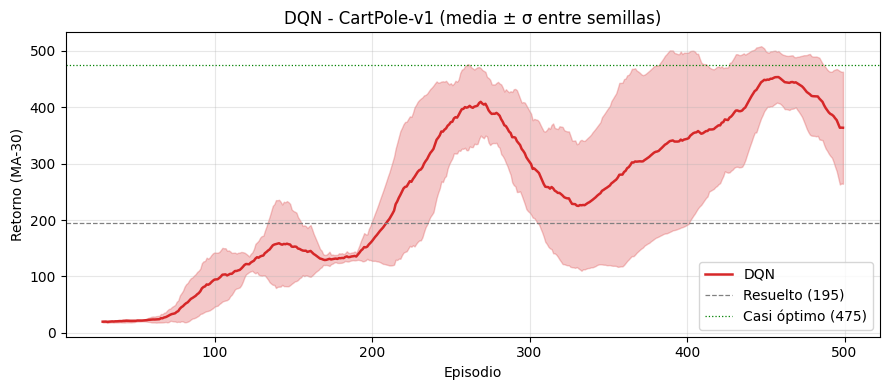

Train media final (media de semillas, ult.50 ep): 384.3 +/- 75.3
Eval greedy final (media de semillas): 433.2 +/- 94.0


In [19]:
# Se visualiza entrenamiento de DQN en CartPole y se reporta resumen train/eval.
fig, ax = plt.subplots(figsize=(9, 4))
plot_band(ax, dqn_cp_all, '#d62728', 'DQN')
ax.axhline(CARTPOLE_SOLVED_RETURN, color='gray', linestyle='--', linewidth=0.9,
           label=f'Resuelto ({CARTPOLE_SOLVED_RETURN:.0f})')
ax.axhline(CARTPOLE_NEAR_OPTIMAL_RETURN, color='green', linestyle=':', linewidth=0.9,
           label=f'Casi óptimo ({CARTPOLE_NEAR_OPTIMAL_RETURN:.0f})')
ax.set_xlabel('Episodio')
ax.set_ylabel(f'Retorno (MA-{SMOOTH_W})')
ax.set_title('DQN - CartPole-v1 (media ± σ entre semillas)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

_cp_train_seed = final_window_seed_means(dqn_cp_all, W_FINAL_CARTPOLE)
_cp_eval_seed = eval_seed_means(dqn_cp_eval)
print(f'Train media final (media de semillas, ult.{W_FINAL_CARTPOLE} ep): {_cp_train_seed.mean():.1f} +/- {_cp_train_seed.std():.1f}')
print(f'Eval greedy final (media de semillas): {_cp_eval_seed.mean():.1f} +/- {_cp_eval_seed.std():.1f}')


In [20]:
# Interpretación dinámica de DQN en CartPole.
_s_train_mean, _s_train_std, _ = seed_mean_stats(final_window_seed_means(sarsa_cp_all, W_FINAL_CARTPOLE))
_s_eval_mean, _s_eval_std, _ = seed_mean_stats(eval_seed_means(sarsa_cp_eval))
_d_train_mean, _d_train_std, _ = seed_mean_stats(final_window_seed_means(dqn_cp_all, W_FINAL_CARTPOLE))
_d_eval_mean, _d_eval_std, _ = seed_mean_stats(eval_seed_means(dqn_cp_eval))
_d_cross_195 = first_smoothed_crossing(dqn_cp_all, CARTPOLE_SOLVED_RETURN)
_d_cross_475 = first_smoothed_crossing(dqn_cp_all, CARTPOLE_NEAR_OPTIMAL_RETURN)
_s_cross_195 = first_smoothed_crossing(sarsa_cp_all, CARTPOLE_SOLVED_RETURN)
_s_cross_475 = first_smoothed_crossing(sarsa_cp_all, CARTPOLE_NEAR_OPTIMAL_RETURN)
_d_best_ep = best_smoothed_episode(dqn_cp_all)
_delta_eval = _d_eval_mean - _s_eval_mean
_delta_eval_pct = 100.0 * _delta_eval / MAX_STEPS_CARTPOLE
_gap = _d_eval_mean - _d_train_mean
_gap_pct = 100.0 * _gap / MAX_STEPS_CARTPOLE
_cmp_eval = compare_at_precision(_d_eval_mean, _s_eval_mean, 2)
_cmp_std = compare_at_precision(_d_eval_std, _s_eval_std, 2)

if _cmp_eval > 0:
    _comparison = (
        f'A dos decimales, DQN queda por encima de SARSA en evaluación greedy (**{_d_eval_mean:.2f}** frente a **{_s_eval_mean:.2f}**). '
        f'La diferencia exacta es de **{_delta_eval:+.2f}** puntos (**{_delta_eval_pct:+.2f}%** del máximo de CartPole).'
    )
elif _cmp_eval < 0:
    _comparison = (
        f'A dos decimales, DQN queda por debajo de SARSA en evaluación greedy (**{_d_eval_mean:.2f}** frente a **{_s_eval_mean:.2f}**). '
        f'La diferencia exacta es de **{_delta_eval:+.2f}** puntos (**{_delta_eval_pct:+.2f}%** del máximo de CartPole).'
    )
else:
    _comparison = (
        f'A la precisión reportada, DQN y SARSA empatan en evaluación greedy (**{_d_eval_mean:.2f}** frente a **{_s_eval_mean:.2f}**). '
        f'La diferencia exacta sin redondeo es **{_delta_eval:+.4f}**.'
    )

if _d_eval_mean >= CARTPOLE_SOLVED_RETURN:
    if _cmp_eval < 0:
        _solved_note = (
            f'Dado que el retorno greedy medio final supera la referencia de **{CARTPOLE_SOLVED_RETURN:.0f}**, DQN sí resuelve CartPole en promedio, '
            'pero no iguala ni el nivel final ni la homogeneidad alcanzados por SARSA.'
        )
    elif _cmp_eval > 0:
        _solved_note = (
            f'Dado que el retorno greedy medio final supera la referencia de **{CARTPOLE_SOLVED_RETURN:.0f}**, DQN resuelve CartPole en promedio '
            'y además aventaja a SARSA en esta ejecución.'
        )
    else:
        _solved_note = (
            f'Dado que el retorno greedy medio final supera la referencia de **{CARTPOLE_SOLVED_RETURN:.0f}**, ambos métodos resuelven CartPole en promedio '
            'en esta ejecución.'
        )
else:
    _solved_note = (
        f'Como el retorno greedy medio final no alcanza la referencia de **{CARTPOLE_SOLVED_RETURN:.0f}**, DQN no llega a resolver CartPole en promedio '
        'con este presupuesto.'
    )

if _cmp_std > 0:
    _stability = f'DQN muestra mayor dispersión entre semillas que SARSA (**{_d_eval_std:.2f}** frente a **{_s_eval_std:.2f}**).'
elif _cmp_std < 0:
    _stability = f'DQN muestra menor dispersión entre semillas que SARSA (**{_d_eval_std:.2f}** frente a **{_s_eval_std:.2f}**).'
else:
    _stability = f'A la precisión reportada, ambos métodos presentan la misma dispersión inter-semillas (**{_d_eval_std:.2f}** frente a **{_s_eval_std:.2f}**).'

_gap_note = (
    f'La evaluación greedy de DQN **{describe_gap(_gap)}** su promedio final de entrenamiento en **{abs(_gap):.2f}** puntos '
    f'(**{abs(_gap_pct):.2f}%** del máximo teórico).'
)

display(Markdown(f'''#### Interpretación — DQN en CartPole-v1

**Desempeño final de la política greedy.**
DQN obtiene **{_d_eval_mean:.2f} ± {_d_eval_std:.2f}** en evaluación greedy y **{_d_train_mean:.2f} ± {_d_train_std:.2f}** en la ventana final de entrenamiento. {_comparison} {_solved_note}

**Dinámica de aprendizaje observada en entrenamiento.**
La media móvil de DQN supera el umbral clásico de CartPole resuelto (**{CARTPOLE_SOLVED_RETURN:.0f}**) en el **{fmt_episode(_d_cross_195)}** y alcanza la franja casi óptima (**{CARTPOLE_NEAR_OPTIMAL_RETURN:.0f} = 95% del máximo**) en el **{fmt_episode(_d_cross_475)}**. Como referencia, SARSA cruza esos mismos hitos en el **{fmt_episode(_s_cross_195)}** y el **{fmt_episode(_s_cross_475)}**. El mejor tramo suavizado de DQN se localiza en el **{fmt_episode(_d_best_ep)}**.

**Estabilidad y coherencia train/eval.**
{_stability}
{_gap_note}

**Lectura metodológica.**
La comparación es ahora interpretable en términos de algoritmo: ambos métodos ven la misma base de Fourier y consumen exploración con el mismo calendario por episodio. Además, el notebook declara explícitamente que `195` es un criterio histórico del entorno y que `475` es un umbral operativo de saturación, de modo que la discusión sobre rapidez de convergencia no depende de barreras ocultas.
'''))


#### Interpretación — DQN en CartPole-v1

**Desempeño final de la política greedy.**
DQN obtiene **433.24 ± 93.96** en evaluación greedy y **384.35 ± 75.31** en la ventana final de entrenamiento. A dos decimales, DQN queda por debajo de SARSA en evaluación greedy (**433.24** frente a **500.00**). La diferencia exacta es de **-66.76** puntos (**-13.35%** del máximo de CartPole). Dado que el retorno greedy medio final supera la referencia de **195**, DQN sí resuelve CartPole en promedio, pero no iguala ni el nivel final ni la homogeneidad alcanzados por SARSA.

**Dinámica de aprendizaje observada en entrenamiento.**
La media móvil de DQN supera el umbral clásico de CartPole resuelto (**195**) en el **episodio 210** y alcanza la franja casi óptima (**475 = 95% del máximo**) en el **no alcanzado en el experimento**. Como referencia, SARSA cruza esos mismos hitos en el **episodio 110** y el **episodio 179**. El mejor tramo suavizado de DQN se localiza en el **episodio 458**.

**Estabilidad y coherencia train/eval.**
DQN muestra mayor dispersión entre semillas que SARSA (**93.96** frente a **0.00**).
La evaluación greedy de DQN **supera** su promedio final de entrenamiento en **48.89** puntos (**9.78%** del máximo teórico).

**Lectura metodológica.**
La comparación es ahora interpretable en términos de algoritmo: ambos métodos ven la misma base de Fourier y consumen exploración con el mismo calendario por episodio. Además, el notebook declara explícitamente que `195` es un criterio histórico del entorno y que `475` es un umbral operativo de saturación, de modo que la discusión sobre rapidez de convergencia no depende de barreras ocultas.


### 2.2 DQN en Tetris

En Tetris, DQN opera sobre el mismo vector de `7` rasgos que SARSA. Esto convierte la comparación en un contraste entre un aproximador lineal on-policy y un aproximador no lineal off-policy sobre idéntica información del tablero.


In [21]:
# Se entrena DQN en Tetris y luego se evalúa la política final de manera determinista.
dqn_tet_all, dqn_tet_eval = None, None
dqn_tet_demo_agent = None

if TETRIS_AVAILABLE:
    print(f'Entrenando DQN Tetris ({N_EP_TETRIS} ep x {len(SEEDS)} semillas)...')
    _tmp_train, _tmp_eval = [], []
    for s in SEEDS:
        print(f'  seed={s}...', end=' ', flush=True)
        rets, agent = train_dqn_tetris(seed=s, return_agent=True)
        eval_rets = evaluate_dqn_tetris(agent)
        print(f'train-ult{W_FINAL_TETRIS}={np.mean(rets[-W_FINAL_TETRIS:]):.3f} | eval={np.mean(eval_rets):.3f}')
        _tmp_train.append(rets)
        _tmp_eval.append(eval_rets)
        if s == SEEDS[0]:
            dqn_tet_demo_agent = agent

    dqn_tet_all  = np.array(_tmp_train)
    dqn_tet_eval = np.array(_tmp_eval)
    print('Listo.')
else:
    print('Tetris no disponible - celda omitida.')


Entrenando DQN Tetris (250 ep x 5 semillas)...
  seed=0... train-ult40=9.675 | eval=9.950
  seed=1... train-ult40=9.775 | eval=9.950
  seed=2... train-ult40=9.775 | eval=9.950
  seed=3... train-ult40=9.825 | eval=9.950
  seed=4... train-ult40=9.850 | eval=9.950
Listo.


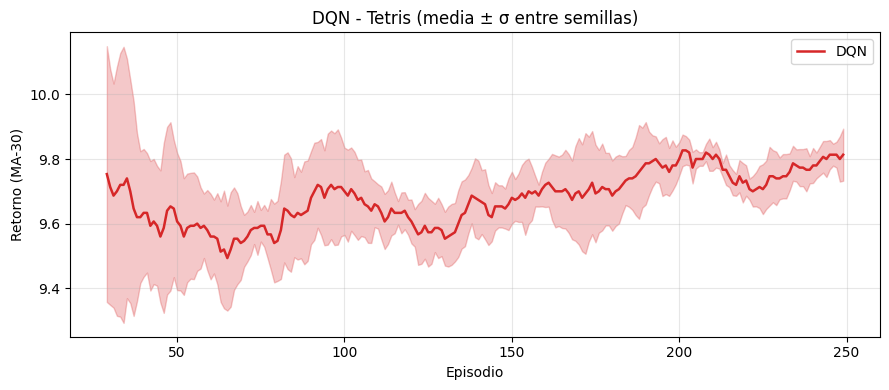

Train media final (media de semillas, ult.40 ep): 9.780 +/- 0.060
Eval greedy final (media de semillas): 9.950 +/- 0.000


In [22]:
# Se visualiza entrenamiento de DQN en Tetris y se reporta resumen train/eval.
if dqn_tet_all is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    plot_band(ax, dqn_tet_all, '#d62728', 'DQN')
    ax.set_xlabel('Episodio')
    ax.set_ylabel(f'Retorno (MA-{SMOOTH_W})')
    ax.set_title('DQN - Tetris (media ± σ entre semillas)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    _tet_train_seed = final_window_seed_means(dqn_tet_all, W_FINAL_TETRIS)
    _tet_eval_seed = eval_seed_means(dqn_tet_eval)
    print(f'Train media final (media de semillas, ult.{W_FINAL_TETRIS} ep): {_tet_train_seed.mean():.3f} +/- {_tet_train_seed.std():.3f}')
    print(f'Eval greedy final (media de semillas): {_tet_eval_seed.mean():.3f} +/- {_tet_eval_seed.std():.3f}')
else:
    print('Sin datos de Tetris.')


In [23]:
# Interpretación dinámica de DQN en Tetris.
if dqn_tet_all is None or sarsa_tet_all is None:
    display(Markdown('''#### Interpretación — DQN en Tetris

Tetris no estuvo disponible en esta ejecución.'''))
else:
    _s_train_mean, _s_train_std, _ = seed_mean_stats(final_window_seed_means(sarsa_tet_all, W_FINAL_TETRIS))
    _s_eval_mean, _s_eval_std, _ = seed_mean_stats(eval_seed_means(sarsa_tet_eval))
    _d_train_mean, _d_train_std, _ = seed_mean_stats(final_window_seed_means(dqn_tet_all, W_FINAL_TETRIS))
    _d_eval_mean, _d_eval_std, _ = seed_mean_stats(eval_seed_means(dqn_tet_eval))
    _d_init_mean, _, _ = seed_mean_stats(initial_window_seed_means(dqn_tet_all, W_FINAL_TETRIS))
    _d_gain = _d_train_mean - _d_init_mean
    _d_best_ep = best_smoothed_episode(dqn_tet_all)
    _delta_eval = _d_eval_mean - _s_eval_mean
    _cmp_eval = compare_at_precision(_d_eval_mean, _s_eval_mean, 3)
    _cmp_std = compare_at_precision(_d_eval_std, _s_eval_std, 3)
    _gap = _d_eval_mean - _d_train_mean

    if _cmp_eval > 0:
        _comparison = (
            f'A tres decimales, DQN queda por encima de SARSA en evaluación greedy (**{_d_eval_mean:.3f}** frente a **{_s_eval_mean:.3f}**). '
            f'La diferencia exacta es **{_delta_eval:+.3f}** puntos.'
        )
        _method_note = 'Bajo esta representación, la no linealidad de DQN sí aporta una ventaja final observable en evaluación greedy.'
    elif _cmp_eval < 0:
        _comparison = (
            f'A tres decimales, DQN queda por debajo de SARSA en evaluación greedy (**{_d_eval_mean:.3f}** frente a **{_s_eval_mean:.3f}**). '
            f'La diferencia exacta es **{_delta_eval:+.3f}** puntos.'
        )
        _method_note = 'Bajo esta representación, la no linealidad de DQN no aporta una ventaja final observable en evaluación greedy.'
    else:
        _comparison = (
            f'A la precisión reportada, DQN y SARSA empatan en evaluación greedy (**{_d_eval_mean:.3f}** frente a **{_s_eval_mean:.3f}**). '
            f'La diferencia exacta sin redondeo es **{_delta_eval:+.6f}**.'
        )
        _method_note = 'Bajo esta representación y este presupuesto, no hay evidencia de una ventaja final de DQN sobre SARSA; las diferencias remanentes pertenecen a la dinámica de entrenamiento, no a la calidad greedy final.'

    if _cmp_std > 0:
        _stability = f'DQN presenta mayor dispersión inter-semillas que SARSA (**{_d_eval_std:.3f}** frente a **{_s_eval_std:.3f}**).'
    elif _cmp_std < 0:
        _stability = f'DQN presenta menor dispersión inter-semillas que SARSA (**{_d_eval_std:.3f}** frente a **{_s_eval_std:.3f}**).'
    else:
        _stability = f'A la precisión reportada, ambos métodos presentan la misma dispersión inter-semillas (**{_d_eval_std:.3f}** frente a **{_s_eval_std:.3f}**).'

    display(Markdown(f'''#### Interpretación — DQN en Tetris

**Desempeño final de la política greedy.**
DQN alcanza **{_d_eval_mean:.3f} ± {_d_eval_std:.3f}** en evaluación greedy y **{_d_train_mean:.3f} ± {_d_train_std:.3f}** en la ventana final de entrenamiento. {_comparison}

**Evolución del aprendizaje.**
La mejora respecto a la ventana inicial de entrenamiento es de **{_d_gain:.3f}** puntos y el mejor tramo suavizado aparece en el **{fmt_episode(_d_best_ep)}**. En Tetris no se usa un umbral de "entorno resuelto" porque este setup no dispone de una referencia externa equivalente a CartPole; la lectura se apoya, por tanto, en retornos medios, pendiente de mejora y estabilidad.

**Estabilidad y coherencia train/eval.**
{_stability}
La evaluación greedy de DQN **{describe_gap(_gap)}** su promedio final de entrenamiento en **{abs(_gap):.3f}** puntos. Esta diferencia ayuda a valorar cuánto del rendimiento observado al final del train se preserva cuando se elimina la exploración.

**Lectura metodológica.**
Como SARSA y DQN reciben exactamente los mismos `7` rasgos del tablero, la comparación en Tetris ya no mezcla efecto de algoritmo con efecto de representación. {_method_note}
'''))


#### Interpretación — DQN en Tetris

**Desempeño final de la política greedy.**
DQN alcanza **9.950 ± 0.000** en evaluación greedy y **9.780 ± 0.060** en la ventana final de entrenamiento. A la precisión reportada, DQN y SARSA empatan en evaluación greedy (**9.950** frente a **9.950**). La diferencia exacta sin redondeo es **+0.000000**.

**Evolución del aprendizaje.**
La mejora respecto a la ventana inicial de entrenamiento es de **0.060** puntos y el mejor tramo suavizado aparece en el **episodio 201**. En Tetris no se usa un umbral de "entorno resuelto" porque este setup no dispone de una referencia externa equivalente a CartPole; la lectura se apoya, por tanto, en retornos medios, pendiente de mejora y estabilidad.

**Estabilidad y coherencia train/eval.**
A la precisión reportada, ambos métodos presentan la misma dispersión inter-semillas (**0.000** frente a **0.000**).
La evaluación greedy de DQN **supera** su promedio final de entrenamiento en **0.170** puntos. Esta diferencia ayuda a valorar cuánto del rendimiento observado al final del train se preserva cuando se elimina la exploración.

**Lectura metodológica.**
Como SARSA y DQN reciben exactamente los mismos `7` rasgos del tablero, la comparación en Tetris ya no mezcla efecto de algoritmo con efecto de representación. Bajo esta representación y este presupuesto, no hay evidencia de una ventaja final de DQN sobre SARSA; las diferencias remanentes pertenecen a la dinámica de entrenamiento, no a la calidad greedy final.


---
## 3. Estudio Comparativo SARSA vs. DQN

La comparación agregada se interpreta bajo el protocolo corregido del notebook:

1. Misma representación por entorno para ambos métodos.
2. Mismo presupuesto de episodios y mismo calendario `epsilon` por episodio.
3. Misma política de semillas en entrenamiento y misma batería greedy final de evaluación.
4. Misma convención estadística: medias finales y desviaciones calculadas a partir de medias por semilla.

Además, se fijan de forma explícita los criterios de lectura cuantitativa:

1. **CartPole resuelto = 195 puntos**. Esta es la referencia histórica del entorno en Gym/Gymnasium y se usa como umbral externo reconocible.
2. **CartPole casi óptimo = 475 puntos**. No es un estándar oficial adicional; se introduce aquí como criterio operativo de saturación, equivalente al `95%` del máximo (`500`), para distinguir entre "resolver" y "control casi perfecto".
3. **Tetris no tiene un umbral canónico equivalente** en este notebook. Por ello no se fuerza una dicotomía éxito/fracaso; la comparación se basa en retornos exactos, variabilidad entre semillas y coherencia entre entrenamiento y evaluación greedy.
4. **`SMOOTH_W` solo se usa para visualización e hitos descriptivos**. La media móvil ayuda a leer la tendencia del gráfico, pero no altera los datos originales ni define el ranking final.
5. **`W_FINAL_CARTPOLE` y `W_FINAL_TETRIS` resumen el régimen terminal**. Se promedia la ventana final de cada semilla para evitar que la conclusión dependa de un único episodio extremo al final del entrenamiento.
6. **Los empates se declaran solo a la precisión reportada**. En vez de introducir umbrales ad hoc de tamaño de efecto, el notebook compara los valores con el mismo redondeo que aparece en tablas y textos.
7. **La comparación sigue siendo una comparación entre configuraciones fijadas**. Es metodológicamente homogénea y defendible, pero no sustituye un barrido exhaustivo de hiperparámetros para cada algoritmo.

Con estas condiciones, la lectura comparativa puede centrarse en rendimiento final, velocidad de aprendizaje y estabilidad entre semillas sin mezclar decisiones heurísticas ocultas con criterios de interpretación.


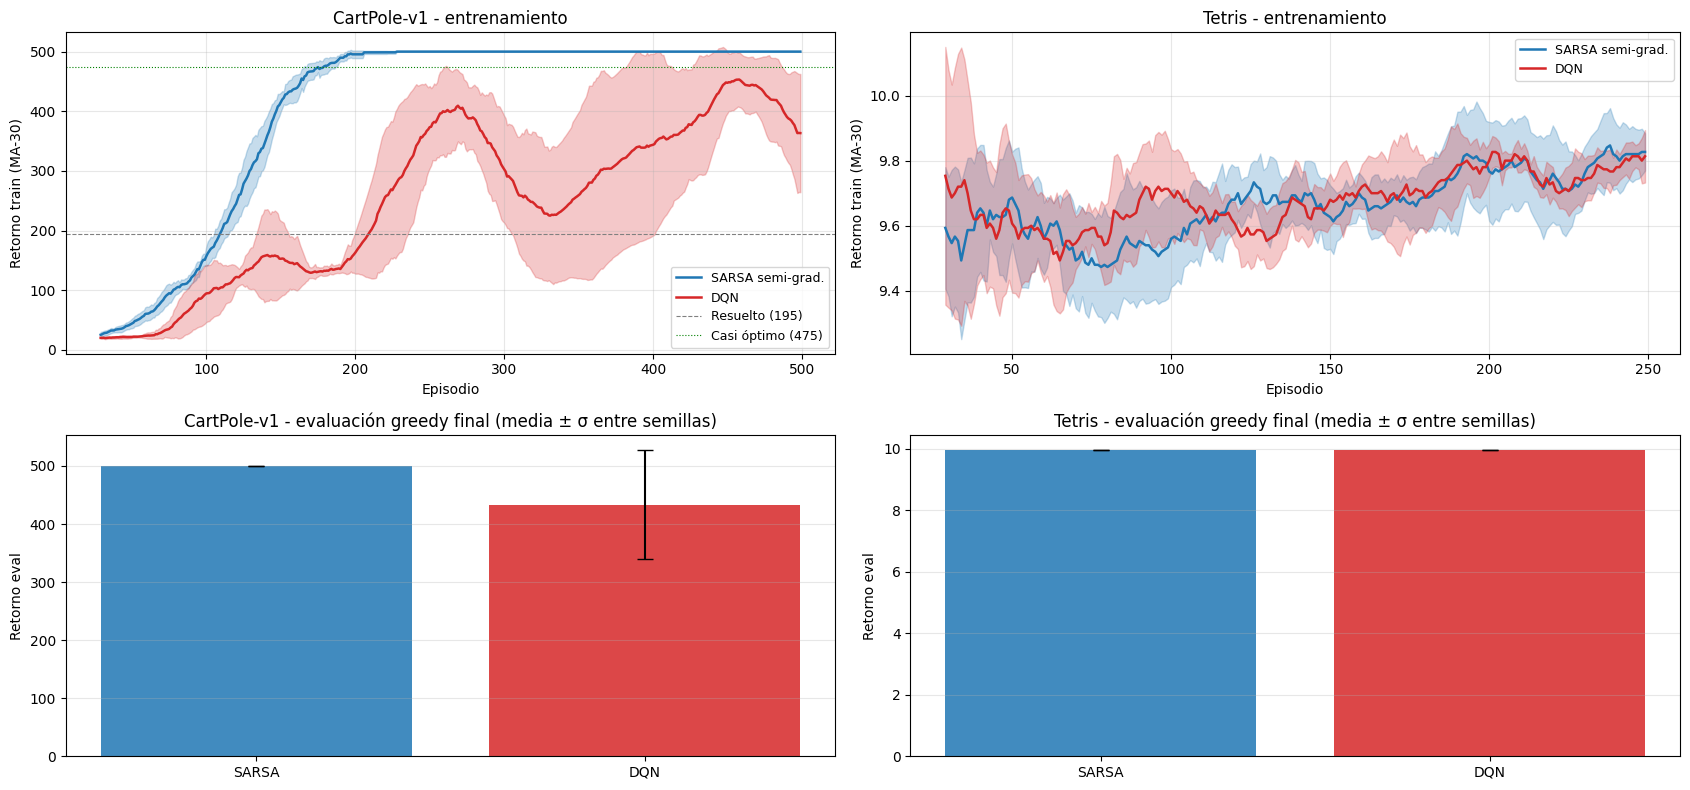

In [24]:
# Se agregan métricas de evaluación por semilla para comparar estabilidad entre algoritmos.
def _eval_seed_means(eval_arr):
    '''Promedia los episodios de evaluación greedy de cada semilla por separado.'''
    if eval_arr is None:
        return None
    return eval_arr.mean(axis=1)


def _plot_eval_bars(ax, means_a, means_b, labels=('SARSA', 'DQN')):
    '''Dibuja barras de evaluación final con error +-sigma entre semillas.'''
    vals, errs = [], []
    for m in (means_a, means_b):
        if m is None:
            vals.append(np.nan)
            errs.append(0.0)
        else:
            vals.append(float(np.mean(m)))
            errs.append(float(np.std(m)))
    x = np.arange(len(labels))
    colors = ['#1f77b4', '#d62728']
    ax.bar(x, vals, yerr=errs, capsize=6, color=colors, alpha=0.85)
    ax.set_xticks(x, labels)
    ax.grid(True, axis='y', alpha=0.3)


n_envs = 1 + int(TETRIS_AVAILABLE and sarsa_tet_all is not None and dqn_tet_all is not None)
fig, axes = plt.subplots(2, n_envs, figsize=(8.5 * n_envs, 8.0))
if n_envs == 1:
    axes = np.array(axes).reshape(2, 1)

ax = axes[0, 0]
plot_band(ax, sarsa_cp_all, '#1f77b4', 'SARSA semi-grad.')
plot_band(ax, dqn_cp_all, '#d62728', 'DQN')
ax.axhline(CARTPOLE_SOLVED_RETURN, color='gray', linestyle='--', linewidth=0.8,
           label=f'Resuelto ({CARTPOLE_SOLVED_RETURN:.0f})')
ax.axhline(CARTPOLE_NEAR_OPTIMAL_RETURN, color='green', linestyle=':', linewidth=0.8,
           label=f'Casi óptimo ({CARTPOLE_NEAR_OPTIMAL_RETURN:.0f})')
ax.set_xlabel('Episodio')
ax.set_ylabel(f'Retorno train (MA-{SMOOTH_W})')
ax.set_title('CartPole-v1 - entrenamiento')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
_plot_eval_bars(ax, _eval_seed_means(sarsa_cp_eval), _eval_seed_means(dqn_cp_eval))
ax.set_title('CartPole-v1 - evaluación greedy final (media ± σ entre semillas)')
ax.set_ylabel('Retorno eval')

if n_envs == 2:
    ax = axes[0, 1]
    plot_band(ax, sarsa_tet_all, '#1f77b4', 'SARSA semi-grad.')
    plot_band(ax, dqn_tet_all, '#d62728', 'DQN')
    ax.set_xlabel('Episodio')
    ax.set_ylabel(f'Retorno train (MA-{SMOOTH_W})')
    ax.set_title('Tetris - entrenamiento')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    _plot_eval_bars(ax, _eval_seed_means(sarsa_tet_eval), _eval_seed_means(dqn_tet_eval))
    ax.set_title('Tetris - evaluación greedy final (media ± σ entre semillas)')
    ax.set_ylabel('Retorno eval')

plt.tight_layout(); plt.show()


In [25]:
# Se consolida una tabla final con métricas de entrenamiento y evaluación por entorno.
def summary_row(algo, env_name, train_arr, eval_arr, w):
    '''Construye una fila comparativa agregando siempre primero por semilla.

    Esto hace homologables la dispersión de entrenamiento y la de evaluación. La columna "Mejor ep (MA)"
    es solo descriptiva: indica dónde la curva media suavizada alcanza su máximo, pero no define el ranking final.
    '''
    if train_arr is None:
        return {
            'Algoritmo': algo,
            'Entorno': env_name,
            'Ventana final': str(w),
            'Train media final': 'N/A',
            'Train std seeds': 'N/A',
            'Gap eval-train': 'N/A',
            'Mejor ep (MA)': 'N/A',
            'Eval greedy media': 'N/A',
            'Eval greedy std': 'N/A',
            'Eval n_seeds': 'N/A',
            'Eval n_episodes': 'N/A',
        }

    train_seed = final_window_seed_means(train_arr, w)
    train_mean = float(train_seed.mean())
    train_std = float(train_seed.std())
    best = best_smoothed_episode(train_arr, SMOOTH_W)

    if eval_arr is None:
        eval_mean, eval_std, n_seeds, n_eval = np.nan, np.nan, 0, 0
    else:
        eval_seed = eval_seed_means(eval_arr)
        eval_mean = float(eval_seed.mean())
        eval_std = float(eval_seed.std())
        n_seeds, n_eval = int(eval_arr.shape[0]), int(eval_arr.shape[1])

    gap = eval_mean - train_mean if np.isfinite(eval_mean) else np.nan
    return {
        'Algoritmo': algo,
        'Entorno': env_name,
        'Ventana final': str(w),
        'Train media final': f'{train_mean:.2f}',
        'Train std seeds': f'{train_std:.2f}',
        'Gap eval-train': f'{gap:+.2f}' if np.isfinite(gap) else 'N/A',
        'Mejor ep (MA)': str(best),
        'Eval greedy media': f'{eval_mean:.2f}' if np.isfinite(eval_mean) else 'N/A',
        'Eval greedy std': f'{eval_std:.2f}' if np.isfinite(eval_std) else 'N/A',
        'Eval n_seeds': str(n_seeds),
        'Eval n_episodes': str(n_eval),
    }


tabla = pd.DataFrame([
    summary_row('SARSA semi-grad.', 'CartPole-v1', sarsa_cp_all, sarsa_cp_eval, W_FINAL_CARTPOLE),
    summary_row('DQN', 'CartPole-v1', dqn_cp_all, dqn_cp_eval, W_FINAL_CARTPOLE),
    summary_row('SARSA semi-grad.', 'Tetris', sarsa_tet_all, sarsa_tet_eval, W_FINAL_TETRIS),
    summary_row('DQN', 'Tetris', dqn_tet_all, dqn_tet_eval, W_FINAL_TETRIS),
])

print('Tabla comparativa final (medias finales y evaluación greedy):')
print('Nota: las desviaciones se calculan entre medias por semilla, no mezclando episodios y semillas.')
print(tabla.to_string(index=False))


Tabla comparativa final (medias finales y evaluación greedy):
Nota: las desviaciones se calculan entre medias por semilla, no mezclando episodios y semillas.
       Algoritmo     Entorno Ventana final Train media final Train std seeds Gap eval-train Mejor ep (MA) Eval greedy media Eval greedy std Eval n_seeds Eval n_episodes
SARSA semi-grad. CartPole-v1            50            500.00            0.00          +0.00           228            500.00            0.00            5              25
             DQN CartPole-v1            50            384.35           75.31         +48.89           458            433.24           93.96            5              25
SARSA semi-grad.      Tetris            40              9.81            0.09          +0.14           238              9.95            0.00            5              20
             DQN      Tetris            40              9.78            0.06          +0.17           201              9.95            0.00            5              

In [26]:
# Conclusiones comparativas dinámicas.
def _metric_bundle(train_arr, eval_arr, w):
    '''Agrupa las métricas finales que se usarán en la conclusión comparativa por entorno.'''
    train_mean, train_std, _ = seed_mean_stats(final_window_seed_means(train_arr, w))
    eval_mean, eval_std, _ = seed_mean_stats(eval_seed_means(eval_arr))
    return {
        'train_mean': train_mean,
        'train_std': train_std,
        'eval_mean': eval_mean,
        'eval_std': eval_std,
        'best_ep': best_smoothed_episode(train_arr),
    }


def _row_md(name, metrics):
    '''Formatea una fila markdown con las métricas agregadas ya homogeneizadas por semilla.'''
    return (
        f"| {name} | {metrics['train_mean']:.2f} ± {metrics['train_std']:.2f} | "
        f"{metrics['eval_mean']:.2f} ± {metrics['eval_std']:.2f} | {metrics['best_ep']:,} |"
    )


_NL = chr(10)

_cp_sarsa = _metric_bundle(sarsa_cp_all, sarsa_cp_eval, W_FINAL_CARTPOLE)
_cp_dqn = _metric_bundle(dqn_cp_all, dqn_cp_eval, W_FINAL_CARTPOLE)
_cp_rank = sorted([
    ('SARSA semi-grad.', _cp_sarsa),
    ('DQN', _cp_dqn),
], key=lambda x: x[1]['eval_mean'], reverse=True)

_cp_delta_eval = _cp_dqn['eval_mean'] - _cp_sarsa['eval_mean']
_cp_delta_std = _cp_dqn['eval_std'] - _cp_sarsa['eval_std']
_cp_gap_sarsa = _cp_sarsa['eval_mean'] - _cp_sarsa['train_mean']
_cp_gap_dqn = _cp_dqn['eval_mean'] - _cp_dqn['train_mean']
_cp_cross_sarsa_195 = first_smoothed_crossing(sarsa_cp_all, CARTPOLE_SOLVED_RETURN)
_cp_cross_dqn_195 = first_smoothed_crossing(dqn_cp_all, CARTPOLE_SOLVED_RETURN)
_cp_cross_sarsa_475 = first_smoothed_crossing(sarsa_cp_all, CARTPOLE_NEAR_OPTIMAL_RETURN)
_cp_cross_dqn_475 = first_smoothed_crossing(dqn_cp_all, CARTPOLE_NEAR_OPTIMAL_RETURN)
_cp_cmp_eval = compare_at_precision(_cp_dqn['eval_mean'], _cp_sarsa['eval_mean'], 2)
_cp_cmp_std = compare_at_precision(_cp_dqn['eval_std'], _cp_sarsa['eval_std'], 2)

_cp_table = (
    '| Método | Train final | Eval greedy final | Mejor ep (MA) |' + _NL +
    '|---|---:|---:|---:|' + _NL +
    _NL.join(_row_md(name, metrics) for name, metrics in _cp_rank)
)

if _cp_cmp_eval > 0:
    _cp_conclusion = (
        f'En CartPole, **DQN** obtiene el mayor retorno greedy final a dos decimales (**{_cp_dqn["eval_mean"]:.2f}** frente a **{_cp_sarsa["eval_mean"]:.2f}**). '
        f'La diferencia exacta es **{_cp_delta_eval:+.2f}** puntos.'
    )
elif _cp_cmp_eval < 0:
    _cp_conclusion = (
        f'En CartPole, **SARSA** obtiene el mayor retorno greedy final a dos decimales (**{_cp_sarsa["eval_mean"]:.2f}** frente a **{_cp_dqn["eval_mean"]:.2f}**). '
        f'La diferencia exacta es **{_cp_delta_eval:+.2f}** puntos.'
    )
else:
    _cp_conclusion = (
        f'A dos decimales, CartPole termina en empate entre ambos métodos (**{_cp_sarsa["eval_mean"]:.2f}** frente a **{_cp_dqn["eval_mean"]:.2f}**). '
        f'La diferencia exacta sin redondeo es **{_cp_delta_eval:+.4f}**.'
    )

if _cp_dqn['eval_mean'] >= CARTPOLE_SOLVED_RETURN:
    if _cp_cmp_eval < 0:
        _cp_resolution = f'DQN también supera la referencia de **{CARTPOLE_SOLVED_RETURN:.0f}**, por lo que resuelve CartPole en promedio; sin embargo, no iguala la rapidez, la estabilidad ni el rendimiento final de SARSA.'
    elif _cp_cmp_eval > 0:
        _cp_resolution = f'DQN supera la referencia de **{CARTPOLE_SOLVED_RETURN:.0f}** y, además, obtiene el mejor rendimiento final del entorno en esta ejecución.'
    else:
        _cp_resolution = f'Ambos métodos superan la referencia de **{CARTPOLE_SOLVED_RETURN:.0f}**, por lo que ambos resuelven CartPole en promedio en esta ejecución.'
else:
    _cp_resolution = f'DQN no alcanza la referencia de **{CARTPOLE_SOLVED_RETURN:.0f}**, así que no llega a resolver CartPole en promedio con este presupuesto.'

if _cp_cmp_std > 0:
    _cp_stability = f'DQN muestra mayor dispersión final entre semillas que SARSA (**{_cp_dqn["eval_std"]:.2f}** frente a **{_cp_sarsa["eval_std"]:.2f}**), con una diferencia exacta de **{_cp_delta_std:+.2f}** puntos.'
elif _cp_cmp_std < 0:
    _cp_stability = f'DQN muestra menor dispersión final entre semillas que SARSA (**{_cp_dqn["eval_std"]:.2f}** frente a **{_cp_sarsa["eval_std"]:.2f}**), con una diferencia exacta de **{_cp_delta_std:+.2f}** puntos.'
else:
    _cp_stability = f'A la precisión reportada, la estabilidad inter-semillas es la misma en ambos métodos (**{_cp_sarsa["eval_std"]:.2f}** frente a **{_cp_dqn["eval_std"]:.2f}**).'

_parts = [
    '## Conclusiones comparativas',
    '',
    '### 1. CartPole-v1',
    '',
    _cp_table,
    '',
    _cp_conclusion,
    '',
    _cp_resolution,
    '',
    f'En el panel superior del gráfico, SARSA cruza la referencia histórica de entorno resuelto (**{CARTPOLE_SOLVED_RETURN:.0f}**) en el **{fmt_episode(_cp_cross_sarsa_195)}** y DQN en el **{fmt_episode(_cp_cross_dqn_195)}**. Para la franja casi óptima (**{CARTPOLE_NEAR_OPTIMAL_RETURN:.0f} = 95% del máximo**), SARSA llega en el **{fmt_episode(_cp_cross_sarsa_475)}** y DQN en el **{fmt_episode(_cp_cross_dqn_475)}**. Estas dos referencias permiten separar rapidez para resolver el entorno de rapidez para saturarlo.',
    '',
    _cp_stability,
    '',
    f'La coherencia entre entrenamiento y evaluación greedy también puede leerse en el gráfico: el gap final es **{_cp_gap_sarsa:+.2f}** para SARSA y **{_cp_gap_dqn:+.2f}** para DQN. En DQN, el signo positivo del gap indica que la política greedy final supera a la política exploratoria promedio observada en la ventana terminal de entrenamiento.',
    '',
]

if sarsa_tet_all is not None and dqn_tet_all is not None:
    _tet_sarsa = _metric_bundle(sarsa_tet_all, sarsa_tet_eval, W_FINAL_TETRIS)
    _tet_dqn = _metric_bundle(dqn_tet_all, dqn_tet_eval, W_FINAL_TETRIS)
    _tet_rank = sorted([
        ('SARSA semi-grad.', _tet_sarsa),
        ('DQN', _tet_dqn),
    ], key=lambda x: x[1]['eval_mean'], reverse=True)
    _tet_delta_eval = _tet_dqn['eval_mean'] - _tet_sarsa['eval_mean']
    _tet_delta_std = _tet_dqn['eval_std'] - _tet_sarsa['eval_std']
    _tet_gap_sarsa = _tet_sarsa['eval_mean'] - _tet_sarsa['train_mean']
    _tet_gap_dqn = _tet_dqn['eval_mean'] - _tet_dqn['train_mean']
    _tet_cmp_eval = compare_at_precision(_tet_dqn['eval_mean'], _tet_sarsa['eval_mean'], 3)
    _tet_cmp_std = compare_at_precision(_tet_dqn['eval_std'], _tet_sarsa['eval_std'], 3)

    _tet_table = (
        '| Método | Train final | Eval greedy final | Mejor ep (MA) |' + _NL +
        '|---|---:|---:|---:|' + _NL +
        _NL.join(_row_md(name, metrics) for name, metrics in _tet_rank)
    )

    if _tet_cmp_eval > 0:
        _tet_conclusion = (
            f'En Tetris, **DQN** obtiene el mayor retorno greedy final a tres decimales (**{_tet_dqn["eval_mean"]:.3f}** frente a **{_tet_sarsa["eval_mean"]:.3f}**). '
            f'La diferencia exacta es **{_tet_delta_eval:+.3f}** puntos.'
        )
        _tet_reading = 'Bajo esta representación y este presupuesto, la no linealidad de DQN sí aporta una ventaja final observable.'
    elif _tet_cmp_eval < 0:
        _tet_conclusion = (
            f'En Tetris, **SARSA** obtiene el mayor retorno greedy final a tres decimales (**{_tet_sarsa["eval_mean"]:.3f}** frente a **{_tet_dqn["eval_mean"]:.3f}**). '
            f'La diferencia exacta es **{_tet_delta_eval:+.3f}** puntos.'
        )
        _tet_reading = 'Bajo esta representación y este presupuesto, la no linealidad de DQN no aporta una ventaja final observable.'
    else:
        _tet_conclusion = (
            f'A tres decimales, Tetris termina en empate entre ambos métodos (**{_tet_sarsa["eval_mean"]:.3f}** frente a **{_tet_dqn["eval_mean"]:.3f}**). '
            f'La diferencia exacta sin redondeo es **{_tet_delta_eval:+.6f}**.'
        )
        _tet_reading = 'Bajo esta representación y este presupuesto, no hay evidencia de una ventaja final de un método sobre el otro; las diferencias remanentes pertenecen a la dinámica de entrenamiento, no a la calidad greedy final.'

    if _tet_cmp_std > 0:
        _tet_stability = f'DQN muestra mayor dispersión inter-semillas que SARSA (**{_tet_dqn["eval_std"]:.3f}** frente a **{_tet_sarsa["eval_std"]:.3f}**), con una diferencia exacta de **{_tet_delta_std:+.3f}** puntos.'
    elif _tet_cmp_std < 0:
        _tet_stability = f'DQN muestra menor dispersión inter-semillas que SARSA (**{_tet_dqn["eval_std"]:.3f}** frente a **{_tet_sarsa["eval_std"]:.3f}**), con una diferencia exacta de **{_tet_delta_std:+.3f}** puntos.'
    else:
        _tet_stability = f'A la precisión reportada, la estabilidad inter-semillas es la misma en ambos métodos (**{_tet_sarsa["eval_std"]:.3f}** frente a **{_tet_dqn["eval_std"]:.3f}**).'

    _parts.extend([
        '### 2. Tetris',
        '',
        _tet_table,
        '',
        _tet_conclusion,
        '',
        _tet_reading,
        '',
        'El panel superior de Tetris debe leerse sin umbral externo de éxito. Lo relevante es la pendiente de mejora, el nivel final alcanzado y el ancho de las bandas entre semillas, porque el entorno no dispone aquí de un criterio estándar análogo al 195 de CartPole.',
        '',
        _tet_stability,
        '',
        f'La coherencia entre entrenamiento y evaluación greedy es de **{_tet_gap_sarsa:+.3f}** para SARSA y **{_tet_gap_dqn:+.3f}** para DQN. En ambos casos, la política greedy final mejora ligeramente el rendimiento medio observado en la ventana terminal de entrenamiento.',
        '',
        '### 3. Síntesis metodológica',
        '',
        'El gráfico superior resume velocidad de aprendizaje y dispersión temporal; el inferior resume robustez de la política greedy final entre semillas. Esta separación evita confundir un entrenamiento aparentemente bueno con una política final verdaderamente consistente.',
        '',
        'El protocolo corregido elimina los tres sesgos centrales de la versión previa del notebook: representación distinta por algoritmo, calendarios `epsilon` incompatibles y agregación estadística que mezclaba episodios con semillas. A partir de esta versión, cualquier diferencia observada debe interpretarse como resultado de la actualización on-policy lineal frente al aprendizaje off-policy con replay y red no lineal sobre la misma información de entrada.',
        '',
        'La lectura, no obstante, sigue siendo la de una comparación controlada entre configuraciones fijadas. Para convertirla en una afirmación fuerte sobre superioridad algorítmica general haría falta un barrido sistemático de hiperparámetros por método y entorno.',
    ])
else:
    _parts.extend([
        '### 2. Síntesis metodológica',
        '',
        'Tetris no estuvo disponible en esta ejecución. Aun así, CartPole queda ya interpretado bajo un protocolo explícito de representación, exploración, ventanas descriptivas y agregación estadística por semilla.',
    ])

display(Markdown(_NL.join(_parts)))


## Conclusiones comparativas

### 1. CartPole-v1

| Método | Train final | Eval greedy final | Mejor ep (MA) |
|---|---:|---:|---:|
| SARSA semi-grad. | 500.00 ± 0.00 | 500.00 ± 0.00 | 228 |
| DQN | 384.35 ± 75.31 | 433.24 ± 93.96 | 458 |

En CartPole, **SARSA** obtiene el mayor retorno greedy final a dos decimales (**500.00** frente a **433.24**). La diferencia exacta es **-66.76** puntos.

DQN también supera la referencia de **195**, por lo que resuelve CartPole en promedio; sin embargo, no iguala la rapidez, la estabilidad ni el rendimiento final de SARSA.

En el panel superior del gráfico, SARSA cruza la referencia histórica de entorno resuelto (**195**) en el **episodio 110** y DQN en el **episodio 210**. Para la franja casi óptima (**475 = 95% del máximo**), SARSA llega en el **episodio 179** y DQN en el **no alcanzado en el experimento**. Estas dos referencias permiten separar rapidez para resolver el entorno de rapidez para saturarlo.

DQN muestra mayor dispersión final entre semillas que SARSA (**93.96** frente a **0.00**), con una diferencia exacta de **+93.96** puntos.

La coherencia entre entrenamiento y evaluación greedy también puede leerse en el gráfico: el gap final es **+0.00** para SARSA y **+48.89** para DQN. En DQN, el signo positivo del gap indica que la política greedy final supera a la política exploratoria promedio observada en la ventana terminal de entrenamiento.

### 2. Tetris

| Método | Train final | Eval greedy final | Mejor ep (MA) |
|---|---:|---:|---:|
| SARSA semi-grad. | 9.81 ± 0.09 | 9.95 ± 0.00 | 238 |
| DQN | 9.78 ± 0.06 | 9.95 ± 0.00 | 201 |

A tres decimales, Tetris termina en empate entre ambos métodos (**9.950** frente a **9.950**). La diferencia exacta sin redondeo es **+0.000000**.

Bajo esta representación y este presupuesto, no hay evidencia de una ventaja final de un método sobre el otro; las diferencias remanentes pertenecen a la dinámica de entrenamiento, no a la calidad greedy final.

El panel superior de Tetris debe leerse sin umbral externo de éxito. Lo relevante es la pendiente de mejora, el nivel final alcanzado y el ancho de las bandas entre semillas, porque el entorno no dispone aquí de un criterio estándar análogo al 195 de CartPole.

A la precisión reportada, la estabilidad inter-semillas es la misma en ambos métodos (**0.000** frente a **0.000**).

La coherencia entre entrenamiento y evaluación greedy es de **+0.140** para SARSA y **+0.170** para DQN. En ambos casos, la política greedy final mejora ligeramente el rendimiento medio observado en la ventana terminal de entrenamiento.

### 3. Síntesis metodológica

El gráfico superior resume velocidad de aprendizaje y dispersión temporal; el inferior resume robustez de la política greedy final entre semillas. Esta separación evita confundir un entrenamiento aparentemente bueno con una política final verdaderamente consistente.

El protocolo corregido elimina los tres sesgos centrales de la versión previa del notebook: representación distinta por algoritmo, calendarios `epsilon` incompatibles y agregación estadística que mezclaba episodios con semillas. A partir de esta versión, cualquier diferencia observada debe interpretarse como resultado de la actualización on-policy lineal frente al aprendizaje off-policy con replay y red no lineal sobre la misma información de entrada.

La lectura, no obstante, sigue siendo la de una comparación controlada entre configuraciones fijadas. Para convertirla en una afirmación fuerte sobre superioridad algorítmica general haría falta un barrido sistemático de hiperparámetros por método y entorno.


---
## 4. Simulación de políticas entrenadas

Se generan animaciones greedy (`epsilon=0`) usando la primera semilla entrenada de cada método. Estas simulaciones son cualitativas y no sustituyen las métricas agregadas anteriores, pero permiten contrastar visualmente el comportamiento inducido por cada política final.


In [27]:
# Se inicializan referencias por defecto para permitir ejecución aislada de esta celda.
sarsa_cp_demo_agent = globals().get('sarsa_cp_demo_agent', None)
sarsa_cp_demo_feat = globals().get('sarsa_cp_demo_feat', None)
dqn_cp_demo_agent = globals().get('dqn_cp_demo_agent', None)
dqn_cp_demo_feat = globals().get('dqn_cp_demo_feat', None)
sarsa_tet_demo_agent = globals().get('sarsa_tet_demo_agent', None)
dqn_tet_demo_agent = globals().get('dqn_tet_demo_agent', None)


def _animate_frames(frames, title='Simulación', fps=20, max_frames=250):
    '''Renderiza una secuencia de frames en HTML para inspección cualitativa de una política greedy.'''
    if frames is None or len(frames) == 0:
        print(f'{title}: no se pudieron obtener frames.')
        return
    frames = frames[:max_frames]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis('off')
    ax.set_title(title)
    im = ax.imshow(frames[0])

    def _update(i):
        im.set_data(frames[i])
        return [im]

    ani = animation.FuncAnimation(fig, _update, frames=len(frames), interval=1000 / fps, blit=True)
    plt.close(fig)
    display(HTML(ani.to_jshtml()))


def rollout_cartpole(policy_fn, seed=123, max_steps=MAX_STEPS_CARTPOLE):
    '''Ejecuta una política en CartPole y devuelve frames y retorno para inspección visual.'''
    env = gym.make('CartPole-v1', render_mode='rgb_array')
    obs, _ = env.reset(seed=seed)
    frames, ret = [], 0.0

    frame = env.render()
    if frame is not None:
        frames.append(frame)

    done, steps = False, 0
    while not done and steps < max_steps:
        a = int(policy_fn(obs))
        obs, r, term, trunc, _ = env.step(a)
        done = term or trunc
        ret += r
        frame = env.render()
        if frame is not None:
            frames.append(frame)
        steps += 1

    env.close()
    return frames, ret


def rollout_tetris(policy_fn, seed=456, max_steps=MAX_STEPS_TETRIS):
    '''Ejecuta una política en Tetris y devuelve frames y retorno; se toleran envoltorios con render parcial.'''
    try:
        env = gym.make(TETRIS_ENV_ID, render_mode='rgb_array')
    except TypeError:
        env = gym.make(TETRIS_ENV_ID)

    obs, _ = env.reset(seed=seed)
    frames, ret = [], 0.0

    try:
        frame = env.render()
        if frame is not None and hasattr(frame, 'shape'):
            frames.append(frame)
    except Exception:
        pass

    done, steps = False, 0
    while not done and steps < max_steps:
        a = int(policy_fn(obs))
        obs, r, term, trunc, _ = env.step(a)
        done = term or trunc
        ret += r
        try:
            frame = env.render()
            if frame is not None and hasattr(frame, 'shape'):
                frames.append(frame)
        except Exception:
            pass
        steps += 1

    env.close()
    return frames, ret


SHOW_SIMULATIONS = False

if SHOW_SIMULATIONS:
    if sarsa_cp_demo_agent is not None:
        def _pol_sarsa_cp(obs):
            phi = sarsa_cp_demo_feat(obs)
            return np.argmax(sarsa_cp_demo_agent.q_values(phi))

        fr, ret = rollout_cartpole(_pol_sarsa_cp, seed=999)
        print(f'SARSA CartPole demo return: {ret:.1f}')
        _animate_frames(fr, title='SARSA - CartPole', fps=20)

    if dqn_cp_demo_agent is not None and dqn_cp_demo_feat is not None:
        @torch.no_grad()
        def _pol_dqn_cp(obs):
            st_np = cartpole_featurize(obs, dqn_cp_demo_feat)
            st = torch.tensor(st_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            return dqn_cp_demo_agent.q_net(st).argmax(1).item()

        fr, ret = rollout_cartpole(_pol_dqn_cp, seed=999)
        print(f'DQN CartPole demo return: {ret:.1f}')
        _animate_frames(fr, title='DQN - CartPole', fps=20)

    if TETRIS_AVAILABLE and sarsa_tet_demo_agent is not None:
        def _pol_sarsa_tet(obs):
            phi = tetris_featurize(obs)
            return np.argmax(sarsa_tet_demo_agent.q_values(phi))

        fr, ret = rollout_tetris(_pol_sarsa_tet, seed=1999)
        print(f'SARSA Tetris demo return: {ret:.1f}')
        _animate_frames(fr, title='SARSA - Tetris', fps=12)

    if TETRIS_AVAILABLE and dqn_tet_demo_agent is not None:
        @torch.no_grad()
        def _pol_dqn_tet(obs):
            st_np = tetris_featurize(obs).astype(np.float32)
            st = torch.tensor(st_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            return dqn_tet_demo_agent.q_net(st).argmax(1).item()

        fr, ret = rollout_tetris(_pol_dqn_tet, seed=1999)
        print(f'DQN Tetris demo return: {ret:.1f}')
        _animate_frames(fr, title='DQN - Tetris', fps=12)
else:
    print('Simulaciones desactivadas por defecto. Activa SHOW_SIMULATIONS=True para generarlas.')


Simulaciones desactivadas por defecto. Activa SHOW_SIMULATIONS=True para generarlas.


In [28]:
# Guarda las simulaciones de demostración en formato GIF.
import numpy as np
import torch
from pathlib import Path

try:
    import imageio.v2 as imageio
except Exception:
    imageio = None

GIF_DIR = Path('report_assets/gifs')
EXPORT_GIFS = False


def save_gif(frames, filename, fps=12):
    '''Serializa una lista de frames en un GIF si la exportación está activada y hay datos disponibles.'''
    if frames is None or len(frames) == 0:
        print(f'No se guardó {filename}: no hay frames disponibles.')
        return
    out_path = GIF_DIR / filename
    duration = 1.0 / max(1, int(fps))
    imageio.mimsave(out_path, [np.asarray(f) for f in frames], format='GIF', duration=duration, loop=0)
    print(f'GIF guardado en: {out_path}')


exports = []

if sarsa_cp_demo_agent is not None and sarsa_cp_demo_feat is not None:
    def _pol_sarsa_cp(obs):
        phi = sarsa_cp_demo_feat(obs)
        return int(np.argmax(sarsa_cp_demo_agent.q_values(phi)))
    exports.append(('sarsa_cartpole.gif', rollout_cartpole, _pol_sarsa_cp, 999, 20))

if dqn_cp_demo_agent is not None and dqn_cp_demo_feat is not None:
    @torch.no_grad()
    def _pol_dqn_cp(obs):
        st_np = cartpole_featurize(obs, dqn_cp_demo_feat)
        st = torch.tensor(st_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        return int(dqn_cp_demo_agent.q_net(st).argmax(1).item())
    exports.append(('dqn_cartpole.gif', rollout_cartpole, _pol_dqn_cp, 999, 20))

if globals().get('TETRIS_AVAILABLE', False) and sarsa_tet_demo_agent is not None:
    def _pol_sarsa_tet(obs):
        phi = tetris_featurize(obs)
        return int(np.argmax(sarsa_tet_demo_agent.q_values(phi)))
    exports.append(('sarsa_tetris.gif', rollout_tetris, _pol_sarsa_tet, 1999, 12))

if globals().get('TETRIS_AVAILABLE', False) and dqn_tet_demo_agent is not None:
    @torch.no_grad()
    def _pol_dqn_tet(obs):
        st_np = tetris_featurize(obs).astype(np.float32)
        st = torch.tensor(st_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        return int(dqn_tet_demo_agent.q_net(st).argmax(1).item())
    exports.append(('dqn_tetris.gif', rollout_tetris, _pol_dqn_tet, 1999, 12))

if not EXPORT_GIFS:
    print('Exportación de GIF desactivada por defecto. Activa EXPORT_GIFS=True para generarla.')
elif imageio is None:
    print('imageio no disponible; se omite la exportación de GIF.')
else:
    GIF_DIR.mkdir(parents=True, exist_ok=True)
    if not exports:
        print('No hay agentes demo disponibles. Ejecuta antes la celda de simulaciones.')
    for filename, rollout_fn, policy_fn, seed, fps in exports:
        frames, ret = rollout_fn(policy_fn, seed=seed)
        save_gif(frames, filename, fps=fps)
        print(f'{filename} | return={ret:.2f}')


Exportación de GIF desactivada por defecto. Activa EXPORT_GIFS=True para generarla.
